In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import os
import sys

import seaborn as sns
import matplotlib.pyplot as plt

import torch

sys.path.append('../../..')
import sherlock as slk

In [2]:
%load_ext autoreload
%autoreload 2

## Load Norman 2019 data

Norman et al. 2019 (CRISPRa screen) — 105 single and 131 double perturbations in K562 cells.  
`slk_prepare_data` standardises the perturbation column to `obs['pert']` with NTC → `'NTC'`.

In [3]:
data = sc.read_h5ad("../../datasets/norman/Norman_2019.h5ad")
data.X = data.layers['counts'].copy()
slk.pp.slk_prepare_data(
    data,
    pert_key='perturbation_name',
    ntc_label='control',
    treatment_key=None,
    inplace=True,
)

p_key = slk.configs.get_config('pert_key')
NTC   = slk.configs.get_config('ntc_label')

all_perts    = data.obs[p_key].unique()
single_perts = [p for p in all_perts if '+' not in str(p) and p != NTC]
combo_perts  = [p for p in all_perts if '+' in str(p)]
print(f"Cells: {data.n_obs}   Genes: {data.n_vars}")
print(f"Single perts: {len(single_perts)}   Combo perts: {len(combo_perts)}   NTC cells: {(data.obs[p_key]==NTC).sum()}")

Cells: 111255   Genes: 19018
Single perts: 105   Combo perts: 131   NTC cells: 11835


## Gene filtering

Keep highly variable genes (seurat_v3, top 2000) **plus** any gene that appears as a perturbation target (single or split from combo) **plus** the top 10 DEGs (by |mean log-normalised expression − NTC|) for every perturbation. This reduces the feature space while ensuring every perturbed gene and its strongest downstream effects are retained.

In [4]:
import scipy.sparse as sp

# Collect all individual gene names that appear as perturbation targets
pert_genes = set()
for p in all_perts:
    if p != NTC:
        for g in str(p).split('+'):
            pert_genes.add(g.strip())

# Norman 2019: use all genes with mean expression > 0.5 UMI per cell (~2800 genes).
# data.X still holds raw counts at this point.
raw_X = data.X
mean_expr = np.array(raw_X.mean(axis=0)).flatten()
expr_mask = mean_expr > 0.5

# Always keep perturbation target genes so their expression is available.
pert_mask = data.var_names.isin(pert_genes)
keep_mask = expr_mask | pert_mask
data = data[:, keep_mask].copy()

n_expr     = int(expr_mask[keep_mask].sum())
n_pert_only = int((pert_mask[keep_mask] & ~expr_mask[keep_mask]).sum())
print(f"Kept {data.n_vars} genes  ({n_expr} with mean > 0.5 UMI + {n_pert_only} pert-only)")
print(f"Pert genes in var_names: {pert_mask[keep_mask].sum()} / {len(pert_genes)}")


Kept 3270 genes  (3190 with mean > 0.5 UMI + 80 pert-only)
Pert genes in var_names: 102 / 105


In [5]:
# top_deg = 10
# # Collect all individual gene names that appear as perturbation targets
# pert_genes = set()
# for p in all_perts:
#     if p != NTC:
#         for g in str(p).split('+'):
#             pert_genes.add(g.strip())

# # HVG selection on raw counts (seurat_v3 expects counts in X)
# sc.pp.highly_variable_genes(data, n_top_genes=2000, flavor='seurat_v3', subset=False)

# # Top-10 DEGs per perturbation (computed on log-normalised copy before subsetting)
# _tmp = data.copy()
# sc.pp.normalize_total(_tmp, target_sum=1e4)
# sc.pp.log1p(_tmp)
# X_norm = _tmp.X.toarray() if hasattr(_tmp.X, 'toarray') else _tmp.X
# ntc_mean = X_norm[(_tmp.obs[p_key] == NTC).values].mean(axis=0)
# deg_genes = set()
# for p in all_perts:
#     if p == NTC:
#         continue
#     mask = (_tmp.obs[p_key] == p).values
#     if mask.sum() == 0:
#         continue
#     lfc = np.abs(X_norm[mask].mean(0) - ntc_mean)
#     deg_genes.update(_tmp.var_names[np.argsort(lfc)[-top_deg:]])
# del _tmp

# # Union: HVG OR perturbation target OR top-10 DEG for any perturbation
# pert_mask = data.var_names.isin(pert_genes)
# deg_mask  = data.var_names.isin(deg_genes)
# keep_mask = data.var['highly_variable'] | pert_mask #| deg_mask TODO ADD FOR DEG
# data = data[:, keep_mask].copy()

# n_hvg      = data.var['highly_variable'].sum()
# n_pert_only = (pert_mask[keep_mask] & ~data.var['highly_variable']).sum()
# n_deg_only  = (deg_mask[keep_mask] & ~data.var['highly_variable'] & ~pert_mask[keep_mask]).sum()
# print(f"Kept {data.n_vars} genes  ({n_hvg} HVG + {n_pert_only} pert-only + {n_deg_only} DEG-only)")
# print(f"Pert genes in var_names: {pert_mask[keep_mask].sum()} / {len(pert_genes)}")

## Compute treatment effects

Ground-truth per-perturbation mean effects (log2-CPM vs NTC), computed for all labels including combinations.

In [6]:
slk.pp.treat_effect(
    data,
    label_col='pert',
    control_label='NTC',
    method='perturbseq',
    inplace=True,
    key='treat_effect',
)
te = data.uns['treat_effect']
print(f"treat_effect: {te.n_obs} perturbations × {te.n_vars} genes")
print(f"  single: {sum('+' not in p and p != NTC for p in te.obs_names)}   combo: {sum('+' in p for p in te.obs_names)}")

100%|██████████| 236/236 [00:04<00:00, 52.77it/s]

treat_effect: 236 perturbations × 3270 genes
  single: 105   combo: 131


## Train VAE (combinatorial mode)

Architecture:
- **Encoder** — background `z0` via `z0_encoder` on NTC; perturbed `z` via shared `z_encoder`
- **Gate** `W[p]` (HardConcrete, shape P×d) — sparse binary mask over latent dims
- **Shift** `z = z0*(1 − W[p]) + A[p]*W[p]` — mechanism shift only in gated dims (linear mode)
- **Decoder** — perturbation-agnostic NB decoder
- **Combinatorial** — labels like `GENE1+GENE2` are split; component shifts are summed at training time
- **Counterfactuals** — abduct NTC `z0`, K-means centroids, apply union(W) gate + Σ A_j*W_j shift

In [7]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


In [8]:
# ── Training split: hold out ceil(20%) of each Norman GT class ──────────
import math, random

random.seed(42)
gi = pd.read_csv('./genetic_interactions.csv')

def canon(s):
    a, b = s.split('+')
    return '+'.join(sorted([a, b]))

gi['combination'] = gi['combination'].apply(canon)
gi['genetic_interaction'] = gi['genetic_interaction'].str.strip()

# For each class, hold out ceil(20%) as validation
val_combos = set()
for cls, grp in gi.groupby('genetic_interaction'):
    n_val = math.ceil(0.2 * len(grp))
    chosen = random.sample(list(grp['combination']), n_val)
    val_combos.update(chosen)

print(f'Total GT pairs: {len(gi)}  |  Held-out val: {len(val_combos)}')

# Build val mask: cells whose combo perturbation is in val_combos
p_key = slk.configs.get_config('pert_key')

def is_val_combo(pert):
    if '+' not in pert:
        return False
    return canon(pert) in val_combos

val_mask = data.obs[p_key].apply(is_val_combo)
data_train = data[~val_mask].copy()
print(f'data shape: {data.shape}  |  data_train shape: {data_train.shape}')
print(f'Val combos held out: {val_combos}')


Total GT pairs: 88  |  Held-out val: 22
data shape: (111255, 3270)  |  data_train shape: (104626, 3270)
Val combos held out: {'FOXA1+FOXL2', 'PTPN12+UBASH3B', 'CBL+CNN1', 'SAMD1+UBASH3B', 'DUSP9+SNAI1', 'CEBPB+PTPN12', 'CEBPE+SPI1', 'DUSP9+PRTG', 'CEBPA+ZC3HAV1', 'FOSB+OSR2', 'MAPK1+PRTG', 'BPGM+SAMD1', 'KLF1+TGFBR2', 'ETS2+PRTG', 'MAP2K6+SPI1', 'FEV+MAP7D1', 'PRTG+TGFBR2', 'PTPN9+UBASH3B', 'PTPN12+UBASH3A', 'DLX2+SNAI1', 'OSR2+PTPN12', 'MAP2K3+MAP2K6'}


Training VAE on cuda …


Epochs:   0%|          | 0/500 [00:00<?, ?it/s]

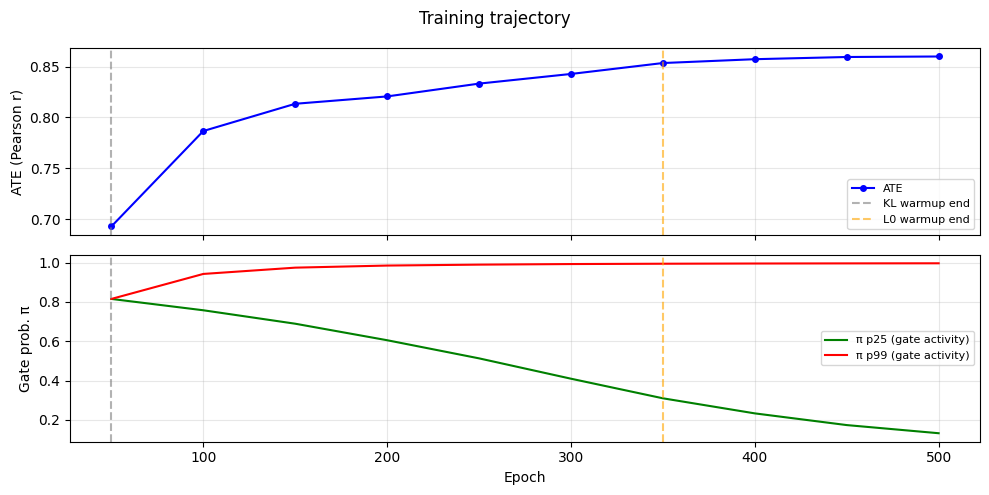

In [9]:
results = slk.tl.run_single(
    data_train,
    model='vae',
    # batch_size=2048,
    # ce_lambda=1e-1,
    l0_lambda=1e-1, #20, #25
    # l1_lambda=10.,
    rank=16,
    shuffle=True,
    num_workers=0,
    device=device,
    synergy=True,
    synergy_rank=6,
    # latent_dim=16,
    num_epochs=500,
    validate_every=50,
    patience=30, #20?
    combinatorial=True,
    debug=True,
    # use_synergy=True,
    n_epochs_l0_warmup=300,
    # ── DEG-align loss ──
    use_de_align_loss=False,
    de_align_lambda=10,    
    de_align_direction_lambda=0,
    de_align_n_bg=256, #128
    de_align_exclude=[], 
    use_go_prior=True,
    # lr=1e-2, #5e-4,
)
model = results['model']

## Save & load

In [10]:
file_name = "norman"

In [11]:
os.makedirs('../results', exist_ok=True)
slk.tl.save_results(results, f'../results/{file_name}.pth')

In [12]:
model = slk.tl.load_results(f'../results/{file_name}.pth')
print(type(model))

<class 'sherlock.tools._models.VAE'>


## Evaluate

`z` — perturbed latent per cell.  
`rho_corr` — Pearson correlation of Cholesky-structured `A[p]` vectors.  
For z_corr, only single-perturbation cells are used.

In [10]:
slk.tl.eval_single(model, data, obsm_key='z', uns_key='results', device=device)
print(list(data.uns['results'].keys()))

['z_corr', 'z_perts', 'z_embed', 'rho_corr', 'rho_perts', 'rho_embed', 'acc', 'z_rho_corr', 'W', 'synergy_enabled', 'synergy_rank', 'counterfactual_effect_size', 'condition_perturbation_interaction', 'conditions', 'synergy_pair_names', 'synergy_pair_norm', 'parent_scale_a', 'parent_scale_b']


In [11]:
syn = model.get_gi(
    data,
    min_cells=5,
)

regress_gi_params:   0%|          | 0/131 [00:00<?, ?pair/s]

In [ ]:
syn.to_csv('./results/syn.csv', index=True)

In [11]:
import importlib
import sherlock.tools._gears as gears_tools
import sherlock.tools._models as models_tools

importlib.reload(gears_tools)
importlib.reload(models_tools)

slk.tl.classify_gi = models_tools.classify_gi

slk.tl.run_gears_gi = gears_tools.run_gears_gi
slk.tl.train_gears = gears_tools.train_gears
slk.tl.predict_gears_combinations = gears_tools.predict_gears_combinations
slk.tl.get_observed_combinations = gears_tools.get_observed_combinations


## GEARS genetic interaction prediction


In [ ]:
gears_combos = slk.tl.get_observed_combinations(
    data,
    pert_key=p_key,
    ntc_label=NTC,
)

gears_run = slk.tl.run_gears_gi(
    data_train,
    combos=gears_combos,
    data_dir="./gears_data",
    dataset_name="norman_sherlock",
    pert_key=p_key,
    ntc_label=NTC,
    split="all",
    seed=1,
    force_reprocess=False,
    # model_path="./gears_model",
    load_path="./gears_model",
    # epochs=1,
    verbose=True,
    quiet_steps=True,
    device=str(device),
)

gears_predictions = gears_run.predictions
gears_gi = gears_run.gi

gears_predictions.to_csv("./results/gears_predictions.csv", index=False)
if gears_gi is not None:
    gears_gi.to_csv("./results/gears_gi.csv", index=False)

skipped_gears_combos = gears_predictions.attrs.get("skipped_combos", [])
missing_gears_genes = gears_predictions.attrs.get("missing_genes", [])
print(f"GEARS requested combinations: {len(gears_combos)}")
print(f"GEARS expression predictions: {len(gears_predictions)} combinations")
if skipped_gears_combos:
    print(
        f"GEARS skipped {len(skipped_gears_combos)} combinations "
        f"with GO-missing genes: {missing_gears_genes}"
    )
if gears_gi is not None:
    print(f"GEARS GI rows: {len(gears_gi)}")
    display(gears_gi.head())
else:
    display(gears_predictions.head())


/opt/conda/envs/perturb/lib/python3.10/site-packages/requests/__init__.py:92: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
Found local copy...


[GEARS] using cached processed dataset at gears_data/norman_sherlock
[GEARS] GO membership filter for single perturbations: patched


These perturbations are not in the GO graph and their perturbation can thus not be predicted
['KIAA1804' 'IER5L+LYL1' 'IER5L']
Local copy of pyg dataset is detected. Loading...
Done!
Creating dataloaders....
Done!


[GEARS] removed 3 cached graph conditions absent from the GO-filtered AnnData
[GEARS] pandas/scipy sparse boolean indexing compatibility: patched
[GEARS] initializing model with hidden_size=64


Start Training...


...

Epoch 1: Train Overall MSE: 5.0006 Validation Overall MSE: 5.0063. 
Train Top 20 DE MSE: 104.7178 Validation Top 20 DE MSE: 104.7161. 
Epoch 2: Train Overall MSE: 5.0052 Validation Overall MSE: 5.0180. 
Train Top 20 DE MSE: 102.8076 Validation Top 20 DE MSE: 102.8248. 
Epoch 3: Train Overall MSE: 4.1187 Validation Overall MSE: 4.1193. 
Train Top 20 DE MSE: 90.5360 Validation Top 20 DE MSE: 90.5255. 
Epoch 4: Train Overall MSE: 3.2185 Validation Overall MSE: 3.2131. 
Train Top 20 DE MSE: 78.3330 Validation Top 20 DE MSE: 78.3406. 
Epoch 5: Train Overall MSE: 3.0381 Validation Overall MSE: 3.0247. 
Train Top 20 DE MSE: 75.1984 Validation Top 20 DE MSE: 75.2118. 
Epoch 6: Train Overall MSE: 2.8737 Validation Overall MSE: 2.8659. 
Train Top 20 DE MSE: 75.1254 Validation Top 20 DE MSE: 75.1131. 
Epoch 7: Train Overall MSE: 3.1514 Validation Overall MSE: 3.1408. 
Train Top 20 DE MSE: 76.4267 Validation Top 20 DE MSE: 76.4430. 
Epoch 8: Train Overall MSE: 2.8881 Validation Overall MSE: 2.8748

[GEARS] saving model to ./gears_unseen_model
[GEARS] skipping 1 requested combos containing perturbations absent from the GO graph: IER5L
[GEARS] predicting 72 singles and 130 combinations once for GI scoring


regress_gi_params:   0%|          | 0/130 [00:00<?, ?pair/s]

GEARS requested combinations: 131
GEARS expression predictions: 130 combinations
GEARS skipped 1 combinations with GO-missing genes: ['IER5L']
GEARS GI rows: 130


,pert_a,pert_b,n_a,n_b,n_ab,magnitude,dominance,model_fit,singles_similarity,singles_to_doubles,...,additive_residual_norm,orthogonal_residual_norm,orthogonal_residual_fraction,cos_fit_resid_a,cos_fit_resid_b,cos_fit_resid_ab,cos_add_resid_a,cos_add_resid_b,cos_add_resid_ab,signed_residual_alignment
AHR+FEV,AHR,FEV,1,1,1,1.272028,0.070431,0.968967,0.988037,0.989688,...,0.196059,0.157662,0.894988,-0.117855,-0.182312,0.019216,-0.600039,-0.647606,-0.484194,-0.484194
AHR+KLF1,AHR,KLF1,1,1,1,0.407288,0.055622,0.714740,0.775950,0.756156,...,0.742424,0.310789,0.581895,-0.448733,0.772890,0.323364,-0.972705,0.073379,-0.749294,-0.749294
BAK1+BCL2L11,BAK1,BCL2L11,1,1,1,1.051140,0.036515,0.549420,0.523180,0.762941,...,1.183195,0.599020,0.892391,0.378471,0.327198,0.662985,-0.179664,-0.918297,0.546134,0.546134
BAK1+KLF1,BAK1,KLF1,1,1,1,0.378383,0.415158,0.286929,0.638885,0.612918,...,0.844732,0.833085,0.986559,0.079824,0.154208,0.903736,-0.484112,-0.784634,-0.023180,-0.023180
BAK1+TMSB4X,BAK1,TMSB4X,1,1,1,0.956805,1.021008,0.833196,0.723408,0.946612,...,0.469375,0.405306,0.992383,0.104040,0.005962,0.418430,-0.732381,-0.506984,-0.235857,-0.235857


Evaluated 86 labeled interactions.
Accuracy:    0.663
Macro F1:    0.657
Weighted F1: 0.660

Classification report:
                        precision    recall  f1-score   support

approximately additive       0.89      0.53      0.67        15
             epistasis       0.70      0.78      0.74         9
            neomorphic       0.46      0.50      0.48        12
          potentiation       0.67      0.67      0.67         6
             redundant       1.00      0.62      0.77         8
           suppression       0.60      0.50      0.55        12
               synergy       0.64      0.88      0.74        24

              accuracy                           0.66        86
             macro avg       0.71      0.64      0.66        86
          weighted avg       0.69      0.66      0.66        86



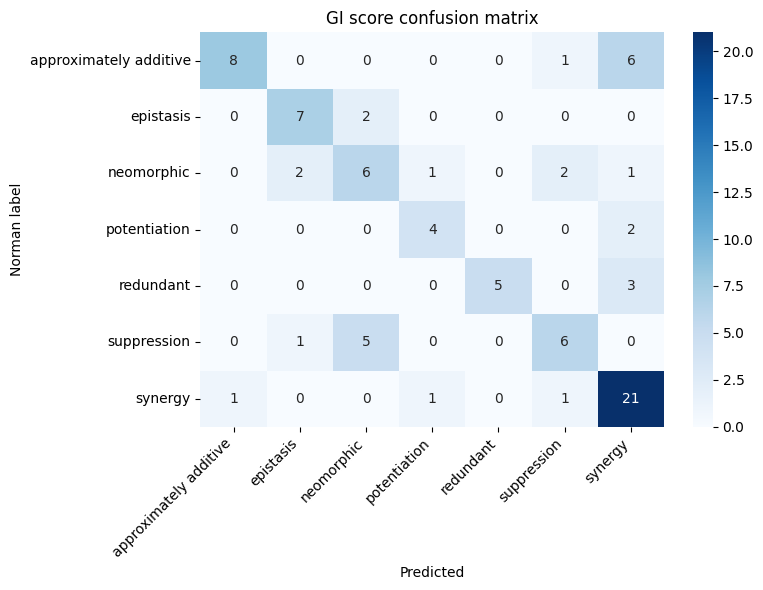

In [12]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

def classify_and_report_gi(
    syn_df,
    gt_path="./genetic_interactions.csv",
    pred_col="predicted_gi",
    inplace=True,
    figsize=(8, 6),
):
    def canon_pair(s):
        s = str(s)
        if "+" not in s:
            return s
        a, b = s.split("+", 1)
        return "+".join(sorted([a.strip(), b.strip()]))

    if not os.path.exists(gt_path):
        raise FileNotFoundError(f"Expected {gt_path} for Norman labels.")

    gt = pd.read_csv(gt_path)
    gt["combination"] = gt["combination"].map(canon_pair)
    gt["genetic_interaction"] = gt["genetic_interaction"].astype(str).str.strip()

    eval_combinations = set(gt["combination"])
    syn_combinations = (
        syn_df["pert_a"].astype(str) + "+" + syn_df["pert_b"].astype(str)
    ).map(canon_pair)

    classified = slk.tl.classify_gi(
        syn_df,
        pred_col=pred_col,
        # fit_mask=syn_combinations.isin(eval_combinations),
        inplace=inplace,
    )

    score_df = classified.copy()
    score_df["combination"] = syn_combinations
    score_df = score_df.merge(
        gt[["combination", "genetic_interaction"]],
        on="combination",
        how="inner",
    )
    score_df = score_df.loc[score_df[pred_col].notna()].copy()

    merge_synergy = {
        "synergy (similar phenotype)": "synergy",
        "synergy (dissimilar phenotype)": "synergy",
    }
    y_true = score_df["genetic_interaction"].astype(str).replace(merge_synergy)
    y_pred = score_df[pred_col].astype(str).replace(merge_synergy)
    labels = sorted(y_true.unique())

    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro", labels=labels)
    weighted_f1 = f1_score(y_true, y_pred, average="weighted", labels=labels)

    print(f"Evaluated {len(score_df)} labeled interactions.")
    print(f"Accuracy:    {acc:.3f}")
    print(f"Macro F1:    {macro_f1:.3f}")
    print(f"Weighted F1: {weighted_f1:.3f}")
    print()
    print("Classification report:")
    print(classification_report(y_true, y_pred, labels=labels, zero_division=0))

    cm = confusion_matrix(y_true, y_pred, labels=labels)
    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels,
        ax=ax,
    )
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Norman label")
    ax.set_title("GI score confusion matrix")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    return classified

syn = classify_and_report_gi(syn)
# gears_gi = classify_and_report_gi(gears_gi)


In [14]:
# ── SHERLOCK (norman.pth) vs. GEARS (run_1) — weighted F1, synergy classes merged ──
GEARS_RUN1_GI_PATH = "./results/norman_figure/gears_runs/gears_gi_run1.csv"

merge_synergy = {
    "synergy (similar phenotype)": "synergy",
    "synergy (dissimilar phenotype)": "synergy",
}


def weighted_f1_vs_gt(df, gt_path="./genetic_interactions.csv", pred_col="predicted_gi", classify=True):
    def canon_pair(s):
        a, b = str(s).split("+", 1)
        return "+".join(sorted([a.strip(), b.strip()]))

    gt = pd.read_csv(gt_path)
    gt["combination"] = gt["combination"].map(canon_pair)
    gt["genetic_interaction"] = gt["genetic_interaction"].astype(str).str.strip()

    work = df.copy()
    if classify:
        work = slk.tl.classify_gi(work, pred_col=pred_col, inplace=True)
    work["combination"] = (
        work["pert_a"].astype(str) + "+" + work["pert_b"].astype(str)
    ).map(canon_pair)

    merged = work.merge(gt[["combination", "genetic_interaction"]], on="combination", how="inner")
    merged = merged.loc[merged[pred_col].notna()].copy()

    y_true = merged["genetic_interaction"].astype(str).replace(merge_synergy)
    y_pred = merged[pred_col].astype(str).replace(merge_synergy)
    labels = sorted(y_true.unique())

    weighted_f1 = f1_score(y_true, y_pred, average="weighted", labels=labels, zero_division=0)
    return weighted_f1, len(merged)


sherlock_f1, sherlock_n = weighted_f1_vs_gt(syn, classify=False)  # syn already classified in the cell above

gears_run1_gi = pd.read_csv(GEARS_RUN1_GI_PATH)
gears_f1, gears_n = weighted_f1_vs_gt(gears_run1_gi, classify=True)

print(f"SHERLOCK (norman.pth):  weighted F1 = {sherlock_f1:.3f}  (n={sherlock_n})")
print(f"GEARS (run_1):          weighted F1 = {gears_f1:.3f}  (n={gears_n})")


SHERLOCK (norman.pth):  weighted F1 = 0.630  (n=86)
GEARS (run_1):          weighted F1 = 0.683  (n=86)


/opt/conda/envs/perturb/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


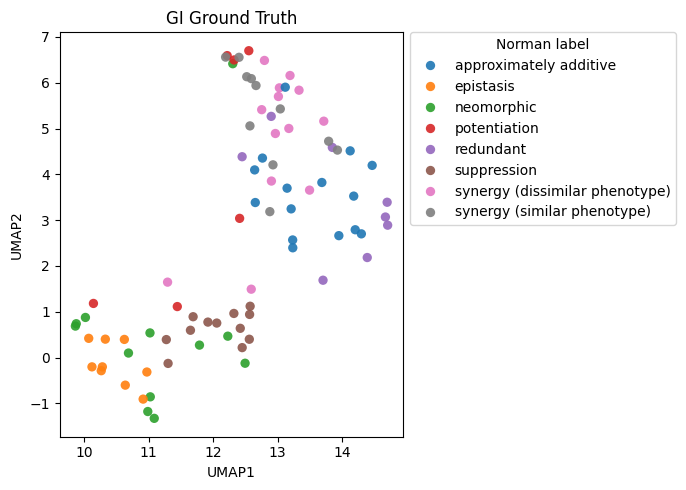

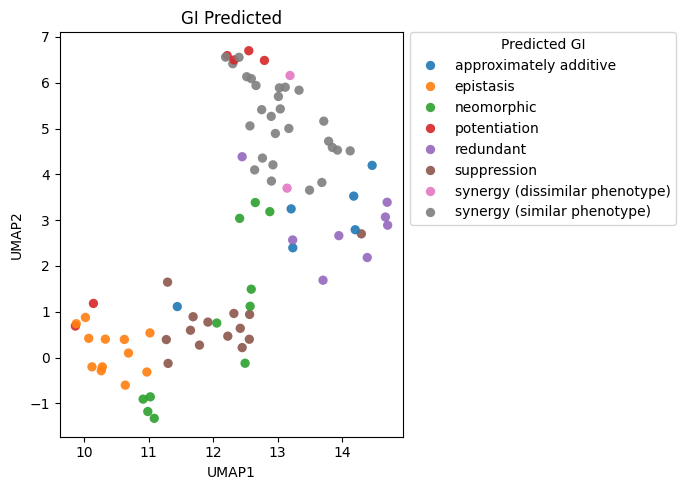

Plotted 86 interactions using 12 metrics.
Helper metrics: ['singles_to_doubles', 'additive_residual_norm', 'dominance', 'parent_dcor_diff', 'equality_contribution', 'singles_similarity', 'norm_ab_over_additive', 'norm_fit_over_ab', 'magnitude', 'model_fit_dcor', 'norm_fit', 'signed_residual_alignment']


,combination,genetic_interaction,predicted_gi,singles_to_doubles,additive_residual_norm,dominance,parent_dcor_diff,equality_contribution,singles_similarity,norm_ab_over_additive,norm_fit_over_ab,magnitude,model_fit_dcor,norm_fit,signed_residual_alignment,umap_1,umap_2
0,AHR+FEV,synergy (dissimilar phenotype),potentiation,0.932417,0.268467,0.015812,0.078084,0.910802,0.582879,1.121159,0.978504,1.543481,0.957683,12.823140,0.546642,12.796088,6.486268
1,AHR+KLF1,epistasis,epistasis,0.674670,0.540904,0.567189,0.679824,0.201309,0.211156,0.868129,0.998941,1.189403,0.915436,6.381303,0.049221,10.069692,0.421143
6,BPGM+SAMD1,approximately additive,approximately additive,0.885181,0.353540,0.201488,0.028852,0.966185,0.693697,0.803423,0.920519,1.107392,0.913555,7.491214,-0.404027,13.210613,3.246585
10,CBFA2T3+FEV,potentiation,potentiation,0.870068,0.823058,0.156917,0.354454,0.578162,0.195268,1.708488,1.029901,2.256386,0.937108,15.548641,0.923191,12.218141,6.591622
11,CBFA2T3+POU3F2,synergy (dissimilar phenotype),synergy (dissimilar phenotype),0.913716,0.398294,0.474486,0.182983,0.799446,0.652694,1.066265,0.986430,1.549497,0.935545,8.059483,0.347973,13.193134,6.157379


In [15]:
# Regular 2D UMAP using Norman six plus top one-vs-rest CSV separators
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

try:
    from umap import UMAP
except ImportError as exc:
    raise ImportError(
        "This cell needs umap-learn. Install it with `pip install umap-learn` "
        "in the notebook environment, then rerun the cell."
    ) from exc

# Start with the exact Norman six, then add the strongest one-vs-rest separator
# metrics found in ./results/syn.csv joined to genetic_interactions.csv. These
# helpers are intentionally raw metrics, not composite scores, to avoid the
# over-separated geometry we saw with hand-built separators.
norman6_metrics = [
    "magnitude",
    "dominance",
    "model_fit_r2_centered",
    "singles_similarity",
    "singles_to_doubles",
    "equality_contribution",
]

helper_metrics = [
    "singles_to_doubles",
    "additive_residual_norm",
    "dominance",
    "parent_dcor_diff",
    "equality_contribution",
    "singles_similarity",
    "norm_ab_over_additive",
    "norm_fit_over_ab",
    "magnitude",
    "model_fit_dcor",
    "norm_fit",
    "signed_residual_alignment",
]

umap_metrics = helper_metrics

def canon_pair(s):
    s = str(s)
    if "+" not in s:
        return s
    a, b = s.split("+", 1)
    return "+".join(sorted([a.strip(), b.strip()]))

plot_df = syn.copy()
plot_df["combination"] = (
    plot_df["pert_a"].astype(str) + "+" + plot_df["pert_b"].astype(str)
).map(canon_pair)

# if "signed_residual_alignment" not in plot_df.columns and "cos_add_resid_ab" in plot_df.columns:
#     print("Using cos_add_resid_ab as a fallback for signed_residual_alignment; rerun get_gi for the exact metric.")
#     plot_df["signed_residual_alignment"] = plot_df["cos_add_resid_ab"]

missing = [c for c in umap_metrics if c not in plot_df.columns]
if missing:
    raise ValueError(f"Missing UMAP metric columns in syn: {missing}")

if "model_corr" not in plot_df.columns:
    print(
        "Rerun get_gi to refresh syn with Norman-style OLS coefficients and R2 model_fit; "
        "this syn may still contain the older robust/correlation fit."
    )

if os.path.exists("./genetic_interactions.csv"):
    gt = pd.read_csv("./genetic_interactions.csv")
    gt["combination"] = gt["combination"].map(canon_pair)
    gt["genetic_interaction"] = gt["genetic_interaction"].astype(str).str.strip()
    plot_df = plot_df.merge(
        gt[["combination", "genetic_interaction"]],
        on="combination",
        how="left",
    )
else:
    plot_df["genetic_interaction"] = "unlabeled"

if "predicted_gi" not in plot_df.columns:
    raise ValueError("Run the GI classification cell before this UMAP cell so syn['predicted_gi'] is available.")

valid = np.isfinite(plot_df[umap_metrics]).all(axis=1)
if valid.sum() < 3:
    raise ValueError(f"Need at least 3 finite rows for UMAP; found {valid.sum()}.")

X = StandardScaler().fit_transform(plot_df.loc[valid, umap_metrics].astype(float))
embedding = UMAP(
    n_components=2,
    n_neighbors=20,
    # min_dist=0.3,
    metric="euclidean",
    random_state=42,
).fit_transform(X)

gi_metric_umap_all = plot_df.loc[
    valid,
    ["combination", "genetic_interaction", "predicted_gi"] + umap_metrics,
].copy()
gi_metric_umap_all["umap_1"] = embedding[:, 0]
gi_metric_umap_all["umap_2"] = embedding[:, 1]

plot_valid = (
    gi_metric_umap_all["genetic_interaction"].notna()
    & gi_metric_umap_all["predicted_gi"].notna()
)
gi_metric_umap = gi_metric_umap_all.loc[plot_valid].copy()

label_values = pd.concat([
    gi_metric_umap["genetic_interaction"],
    gi_metric_umap["predicted_gi"],
]).dropna().astype(str)
label_order = sorted(label_values.unique())
label_palette = dict(zip(label_order, sns.color_palette("tab10", n_colors=len(label_order))))

fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(
    data=gi_metric_umap,
    x="umap_1",
    y="umap_2",
    hue="genetic_interaction",
    hue_order=label_order,
    palette=label_palette,
    s=45,
    alpha=0.9,
    linewidth=0,
    ax=ax,
)
ax.set_title("GI Ground Truth")
ax.set_xlabel("UMAP1")
ax.set_ylabel("UMAP2")
ax.legend(title="Norman label", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(
    data=gi_metric_umap,
    x="umap_1",
    y="umap_2",
    hue="predicted_gi",
    hue_order=label_order,
    palette=label_palette,
    s=45,
    alpha=0.9,
    linewidth=0,
    ax=ax,
)
ax.set_title("GI Predicted")
ax.set_xlabel("UMAP1")
ax.set_ylabel("UMAP2")
ax.legend(title="Predicted GI", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
plt.tight_layout()
plt.show()

print(f"Plotted {len(gi_metric_umap)} interactions using {len(umap_metrics)} metrics.")
print("Helper metrics:", helper_metrics)
gi_metric_umap.head()


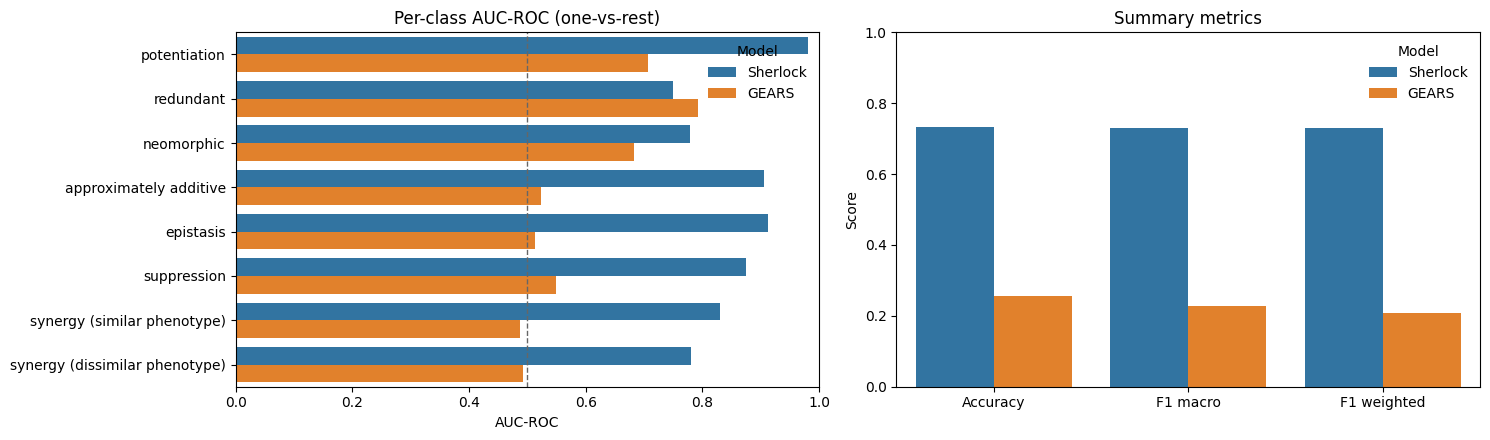

In [101]:
from sklearn.metrics import roc_auc_score, f1_score


def canon_pair(s):
    s = str(s)
    if "+" not in s:
        return s
    a, b = s.split("+", 1)
    return "+".join(sorted([a.strip(), b.strip()]))


def gi_combinations(df):
    if "combination" in df.columns:
        return df["combination"].astype(str).map(canon_pair)
    if {"pert_a", "pert_b"}.issubset(df.columns):
        return (df["pert_a"].astype(str) + "+" + df["pert_b"].astype(str)).map(canon_pair)
    return pd.Series(df.index.astype(str), index=df.index).map(canon_pair)


def evaluate_gi_predictions(df, model_name, gt):
    work = df.copy()
    combos = gi_combinations(work)
    eval_combinations = set(gt["combination"])
    work = slk.tl.classify_gi(
        work,
        fit_mask=combos.isin(eval_combinations),
        inplace=True,
    )
    work["combination"] = combos
    eval_df = work.merge(
        gt[["combination", "genetic_interaction"]],
        on="combination",
        how="inner",
    )
    eval_df = eval_df.loc[eval_df["predicted_gi"].notna()].copy()

    y_true = eval_df["genetic_interaction"].astype(str)
    y_pred = eval_df["predicted_gi"].astype(str)
    labels = sorted(set(y_true.unique()) | set(y_pred.unique()))

    summary = pd.DataFrame([
        {"model": model_name, "metric": "Accuracy", "score": float((y_true == y_pred).mean())},
        {"model": model_name, "metric": "F1 macro", "score": f1_score(y_true, y_pred, average="macro", zero_division=0)},
        {"model": model_name, "metric": "F1 weighted", "score": f1_score(y_true, y_pred, average="weighted", zero_division=0)},
    ])

    auc_rows = []
    for cls in labels:
        true_bin = (y_true == cls).astype(int)
        pred_bin = (y_pred == cls).astype(int)
        n_pos = int(true_bin.sum())
        auc = roc_auc_score(true_bin, pred_bin) if 0 < n_pos < len(true_bin) else np.nan
        auc_rows.append({
            "model": model_name,
            "class": cls,
            "n_positive": n_pos,
            "f1": f1_score(true_bin, pred_bin, zero_division=0),
            "auc_roc": auc,
        })
    return eval_df, pd.DataFrame(auc_rows), summary


gi = pd.read_csv("./genetic_interactions.csv")
gi["combination"] = gi["combination"].map(canon_pair)
gi["genetic_interaction"] = gi["genetic_interaction"].astype(str).str.strip()

_eval_frames = []
_auc_frames = []
_summary_frames = []
for _name, _df in [("Sherlock", syn), ("GEARS", gears_gi)]:
    _eval_df, _auc_df, _summary_df = evaluate_gi_predictions(_df, _name, gi)
    _eval_frames.append(_eval_df.assign(model=_name))
    _auc_frames.append(_auc_df)
    _summary_frames.append(_summary_df)

gi_auc_eval = pd.concat(_eval_frames, ignore_index=True)
gi_auc_df = pd.concat(_auc_frames, ignore_index=True)
gi_summary_df = pd.concat(_summary_frames, ignore_index=True)

class_order = (
    gi_auc_df.groupby("class")["auc_roc"]
    .mean()
    .sort_values(ascending=False)
    .index
    .tolist()
)
metric_order = ["Accuracy", "F1 macro", "F1 weighted"]

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
sns.barplot(
    data=gi_auc_df,
    y="class",
    x="auc_roc",
    hue="model",
    order=class_order,
    ax=axes[0],
)
axes[0].axvline(0.5, color="0.4", linestyle="--", linewidth=1)
axes[0].set_xlabel("AUC-ROC")
axes[0].set_ylabel("")
axes[0].set_title("Per-class AUC-ROC (one-vs-rest)")
axes[0].set_xlim(0, 1)
axes[0].legend(title="Model", frameon=False)

sns.barplot(
    data=gi_summary_df,
    x="metric",
    y="score",
    hue="model",
    order=metric_order,
    ax=axes[1],
)
axes[1].set_ylim(0, 1)
axes[1].set_xlabel("")
axes[1].set_ylabel("Score")
axes[1].set_title("Summary metrics")
axes[1].legend(title="Model", frameon=False)

plt.tight_layout()
plt.show()


In [ ]:
resid = model.get_interaction_residuals(data, obsm_key="z", syn_df=syn)

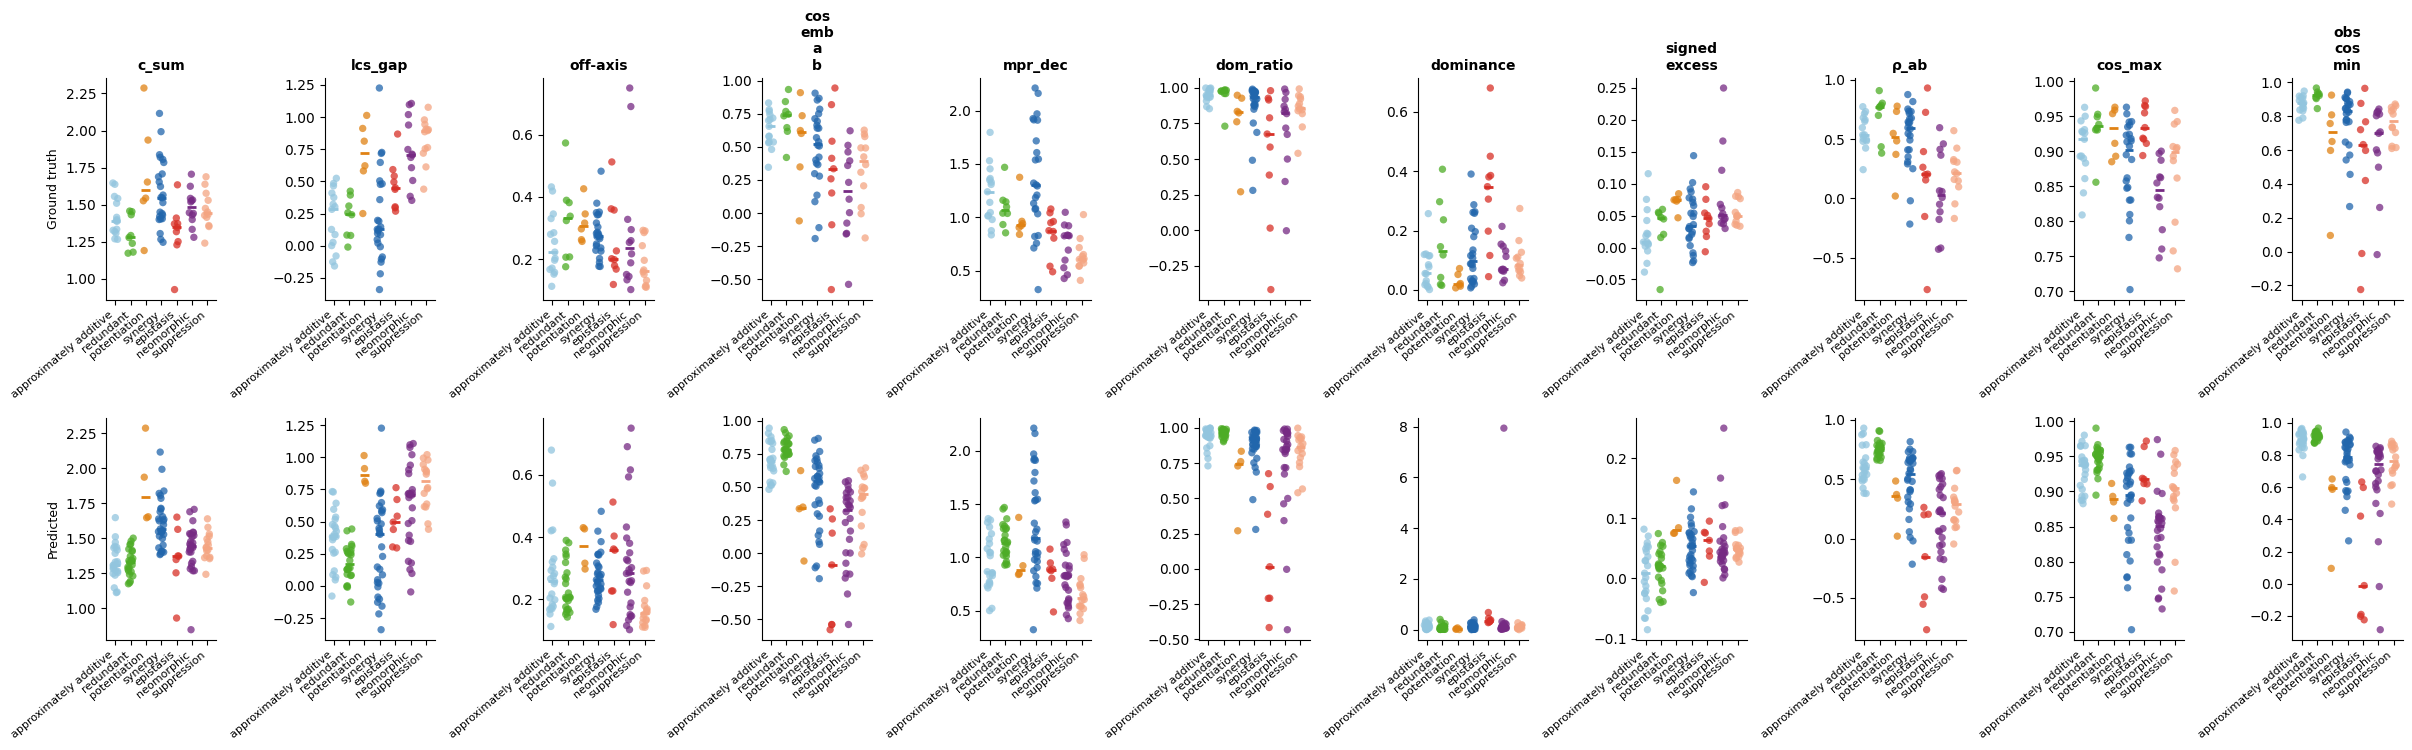

In [ ]:
gt_series = pd.Series({
    p: gi_c.loc[canon(p), 'genetic_interaction'] if canon(p) in gi_c.index else float('nan')
    for p in resid['pairs']
})

fig, axs = slk.pl.plot_feature_stripplot(syn, gt_labels=gt_series)


In [ ]:
syn[syn['classification'] == 'suppression']

,pert_a,pert_b,dominant_pert,n_a,n_b,n_ab,mag_a,mag_b,mag_ab,cos_a_b,cos_ab_a,cos_ab_b,cos_ab_shared,proj_residual,proj_residual_norm,dom_residual,interaction_score,classification


In [ ]:
syn['proj_residual_norm'].min()

np.float64(0.05474448689884319)

In [ ]:
syn[syn.index.str.contains('AHR')]

,pert_a,pert_b,dominant_pert,n_a,n_b,n_ab,mag_a,mag_b,mag_ab,cos_a_b,cos_ab_a,cos_ab_b,cos_ab_shared,proj_residual,proj_residual_norm,dom_residual,interaction_score,classification
AHR+FEV,AHR,FEV,None,558,703,276,3.941916,4.974514,5.922541,0.610511,0.880839,0.882845,0.982707,1.819495,0.454803,1.538136,0.532850,mixed / ambiguous
AHR+KLF1,AHR,KLF1,None,558,1954,481,3.941916,4.891161,5.821764,0.420770,0.807641,0.863787,0.991542,2.050072,0.550732,1.753865,0.580031,synergy (dissimilar phenotype)


/var/tmp/ipykernel_509264/1342186826.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


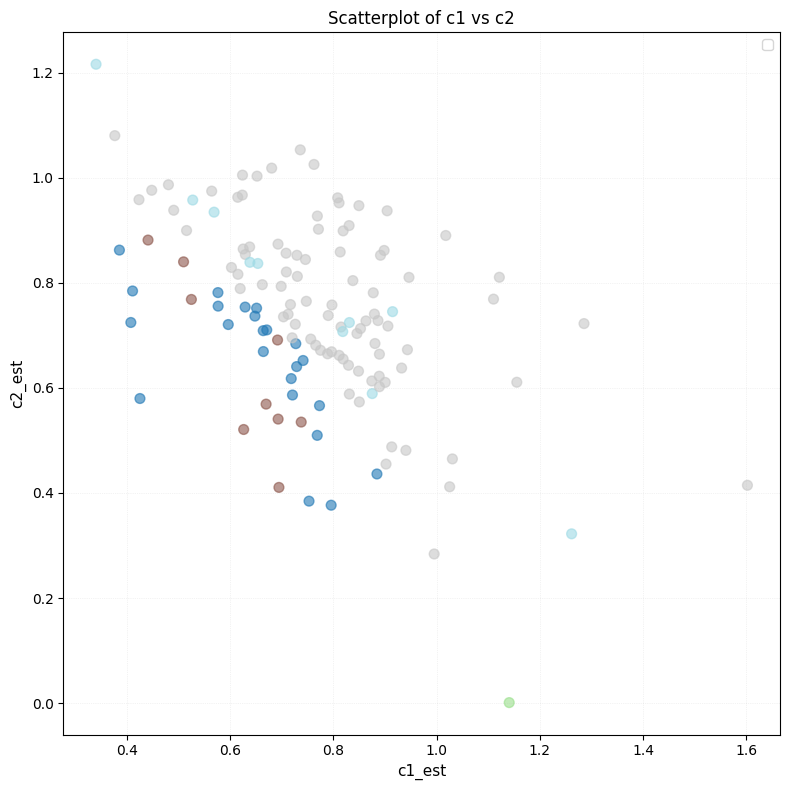

In [ ]:
fig, ax = plt.subplots(figsize=(8, 8))
scatter = ax.scatter(syn['c1'], syn['c2'], 
                     c=pd.Categorical(syn['classification']).codes,
                     s=50, alpha=0.6, cmap='tab20')
ax.set_xlabel('c1_est', fontsize=11)
ax.set_ylabel('c2_est', fontsize=11)
ax.set_title('Scatterplot of c1 vs c2')
ax.grid(True, linestyle=':', linewidth=0.5, alpha=0.3)

plt.legend()

plt.tight_layout()
plt.show()

In [100]:
syn[syn.index.str.contains('CNN1')]

,pert_a,pert_b,n_a,n_b,n_ab,magnitude,dominance,model_fit,singles_similarity,singles_to_doubles,...,orthogonal_residual_norm,orthogonal_residual_fraction,cos_fit_resid_a,cos_fit_resid_b,cos_fit_resid_ab,cos_add_resid_a,cos_add_resid_b,cos_add_resid_ab,signed_residual_alignment,predicted_gi
CBL+CNN1,CBL,CNN1,663,765,348,1.610618,0.247715,0.744570,0.802511,0.822162,...,0.453537,0.897382,0.165652,0.376632,0.738551,0.258377,0.521653,0.827152,0.827152,synergy (dissimilar phenotype)
CEBPE+CNN1,CEBPE,CNN1,1230,765,237,0.915382,0.166654,0.831525,0.342524,0.860740,...,0.393033,0.957550,-0.223410,-0.206838,0.112771,-0.876942,-0.365392,-0.651360,-0.651360,suppression
CNN1+ETS2,CNN1,ETS2,765,1201,904,1.114802,0.154116,0.810710,0.202504,0.747203,...,0.409691,0.941657,-0.336557,0.083959,0.155185,-0.267589,-0.529961,-0.257875,-0.257875,suppression
CNN1+MAPK1,CNN1,MAPK1,765,763,398,1.054570,0.083560,0.863593,0.179845,0.834298,...,0.355441,0.962385,-0.248824,-0.069616,0.173328,-0.586268,-0.374728,-0.352700,-0.352700,suppression
CNN1+UBASH3A,CNN1,UBASH3A,765,817,177,2.213669,0.015807,0.771698,0.573246,0.820089,...,0.438117,0.916928,0.300087,-0.071009,0.642619,0.680257,0.292342,0.920284,0.920284,potentiation
CNN1+UBASH3B,CNN1,UBASH3B,765,1201,401,1.742207,0.005571,0.764809,0.800638,0.889573,...,0.386555,0.797077,0.449687,0.088925,0.717520,0.642847,0.312793,0.863875,0.863875,synergy (dissimilar phenotype)


In [ ]:
mask = (syn['c1_est'] < 1) & (syn['c2_est'] < 1) & (syn['cos_ab_shared'] > 0.9)
syn[mask]

,pert_a,pert_b,dominant_pert,n_a,n_b,n_ab,mag_a,mag_b,mag_ab,cos_a_b,cos_ab_a,cos_ab_b,cos_ab_shared,proj_residual,proj_residual_norm,dom_residual,interaction_score,c1_est,c2_est,classification
AHR+FEV,AHR,FEV,None,558,703,276,3.941916,4.974514,5.922541,0.610511,0.880839,0.882845,0.982707,1.819495,0.454803,1.538136,0.532850,0.818805,0.654971,mixed / ambiguous
AHR+KLF1,AHR,KLF1,None,558,1954,481,3.941916,4.891161,5.821764,0.420770,0.807641,0.863787,0.991542,2.050072,0.550732,1.753865,0.580031,0.797144,0.757814,synergy (dissimilar phenotype)
BAK1+BCL2L11,BAK1,BCL2L11,None,1451,582,175,2.935870,1.745280,2.089697,0.630667,0.902791,0.860994,0.976670,-0.072497,-0.034303,-0.131721,0.220363,0.425219,0.579793,approximately additive
BAK1+TMSB4X,BAK1,TMSB4X,None,1451,542,328,2.935870,6.341323,7.170727,0.841165,0.928753,0.973947,0.991537,2.659448,0.597549,2.578473,0.616574,0.914559,0.745169,synergy (similar phenotype)
BCL2L11+TGFBR2,BCL2L11,TGFBR2,None,582,644,460,1.745280,2.488639,2.555222,0.728510,0.837299,0.968551,0.971249,0.513718,0.261031,0.594816,0.368345,0.410887,0.784541,approximately additive
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SNAI1+UBASH3B,SNAI1,UBASH3B,None,466,1201,299,2.605630,2.387699,3.416295,0.140966,0.711215,0.759143,0.973356,1.439531,0.763378,1.215953,0.872166,0.808242,0.961840,neomorphic
SNAI1+ZBTB10,SNAI1,ZBTB10,None,466,160,100,2.605630,3.301227,4.128412,0.748947,0.919055,0.903601,0.974544,1.261472,0.456749,1.255202,0.570248,0.874364,0.613146,mixed / ambiguous
TBX2+TBX3,TBX2,TBX3,None,689,689,1164,5.853789,5.160986,7.063935,0.582287,0.895606,0.876565,0.996203,2.138498,0.436552,1.897020,0.453020,0.703276,0.735289,approximately additive
UBASH3A+UBASH3B,UBASH3A,UBASH3B,None,817,1201,554,1.439526,2.387699,2.577721,0.737077,0.804000,0.957422,0.945016,0.652587,0.365923,0.743598,0.552119,0.385433,0.862340,mixed / ambiguous


<Axes: xlabel='proj_residual_norm', ylabel='Count'>

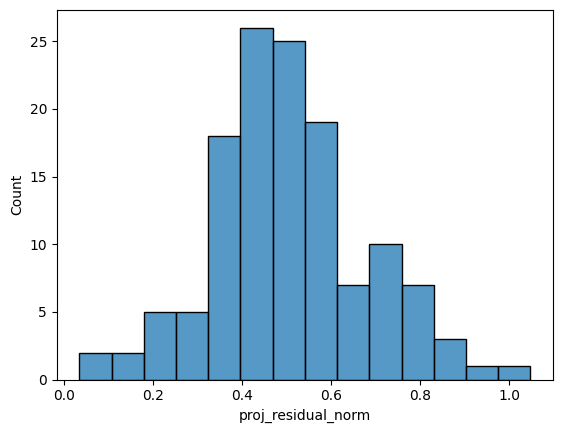

In [ ]:
sns.histplot(np.abs(syn['proj_residual_norm']))

<Axes: >

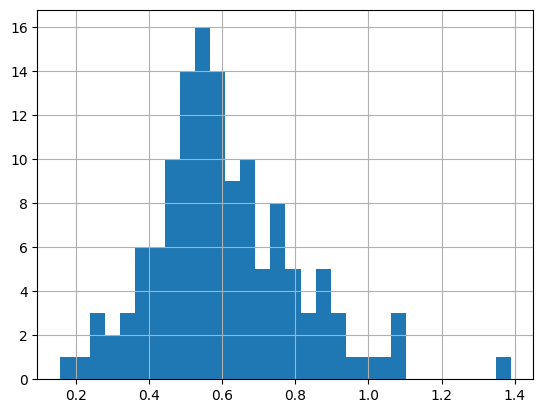

In [ ]:
syn['interaction_score'].hist(bins=30)

In [ ]:
data.layers['counts']

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 59821143 stored elements and shape (111255, 2040)>

In [ ]:
test['class'].value_counts()

class
suppression               74
epistasis                 27
neomorphic                10
approximately additive    10
mixed / ambiguous          5
redundant                  4
weak / undefined           1
Name: count, dtype: int64

In [ ]:
syn[syn.index.str.contains('CDKN1C')]

,pert_a,pert_b,dominant_pert,n_a,n_b,n_ab,mag_a,mag_b,mag_ab,cos_a_b,cos_ab_a,cos_ab_b,cos_ab_shared,proj_residual,proj_residual_norm,dom_residual,interaction_score,classification
CDKN1A+CDKN1C,CDKN1A,CDKN1C,None,360,229,125,3.482069,2.269341,3.484576,0.866935,0.958292,0.955094,0.990200,-2.106362,-0.379061,-2.110199,0.391920,suppression
CDKN1B+CDKN1C,CDKN1B,CDKN1C,None,549,229,107,2.096409,2.269341,2.736934,0.925480,0.975455,0.966404,0.989539,-1.575341,-0.367757,-1.526885,0.379509,suppression


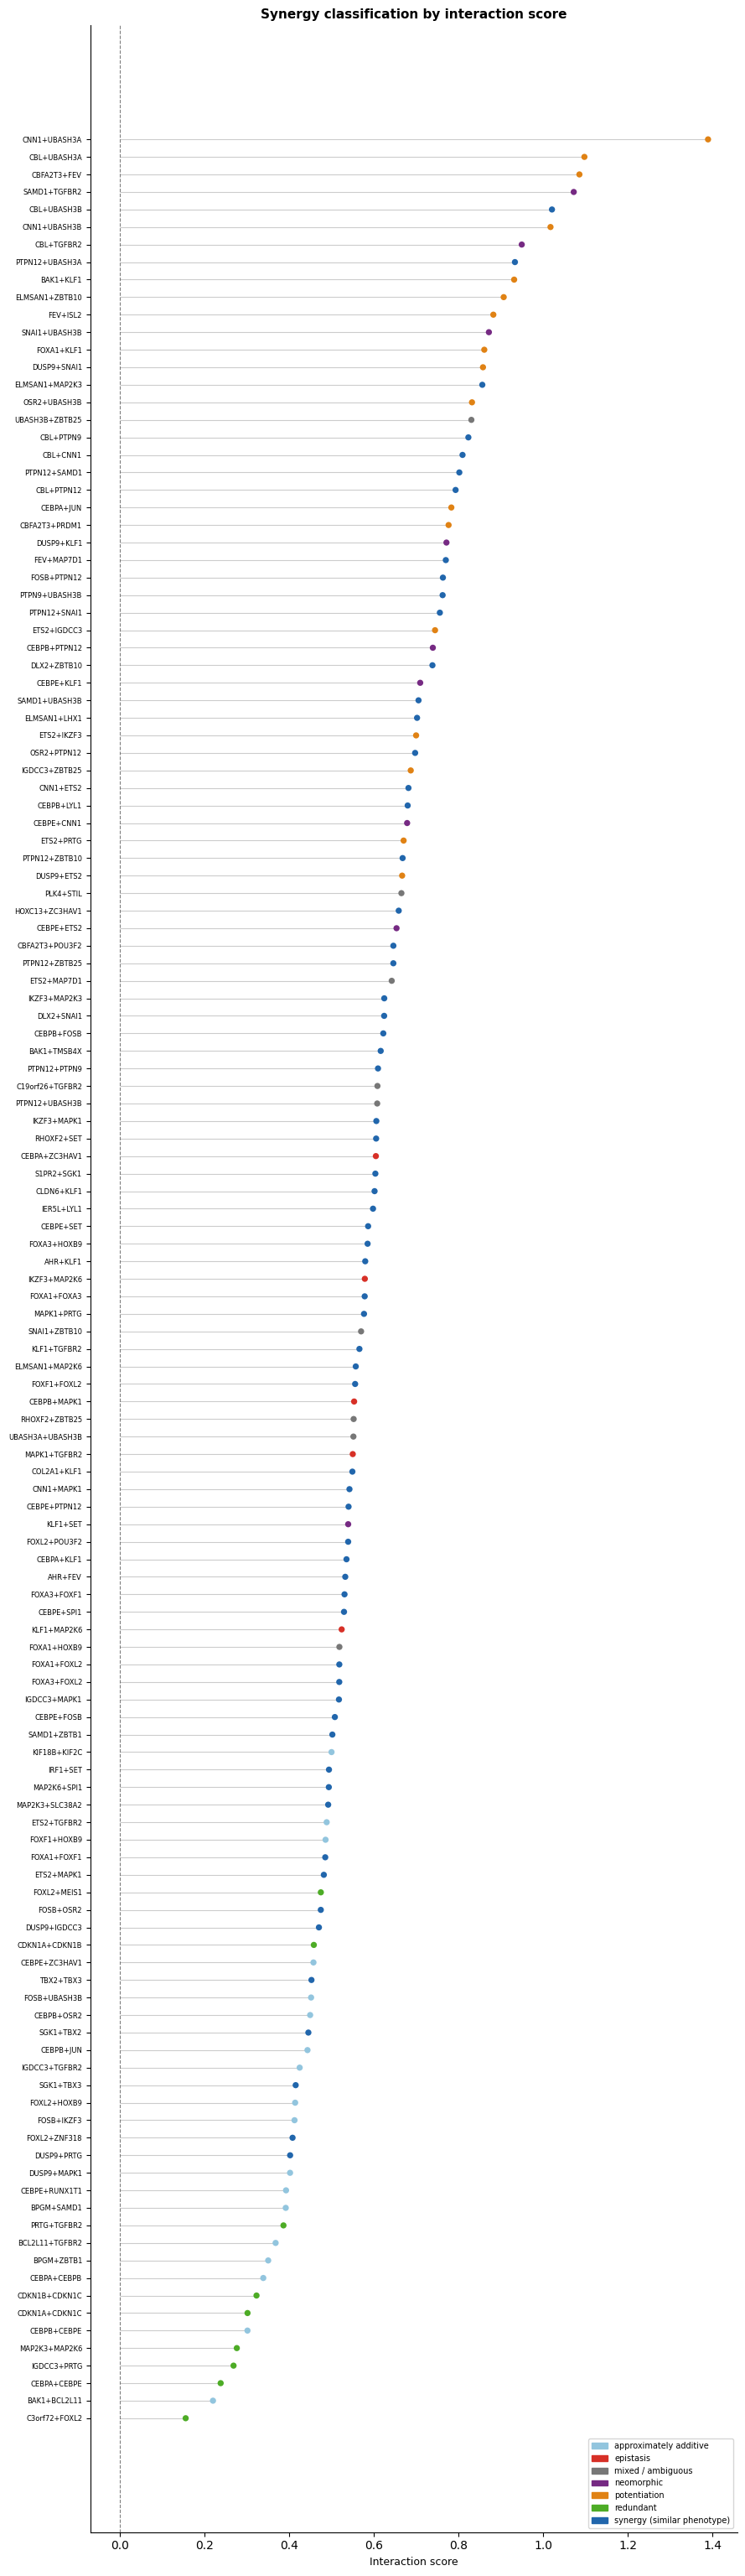

In [ ]:
slk.pl.plot_synergy(data)

In [ ]:
syn[syn.index.str.contains('CEBPE')]

,pert_a,pert_b,dominant_pert,n_a,n_b,n_ab,cos_a_b,cos_ab_a,cos_ab_b,cos_ab_shared,proj_residual,dom_residual,interaction_score,classification
CEBPA+CEBPE,CEBPA,CEBPE,None,458,1230,179,0.793115,0.920834,0.947059,0.986354,0.715003,0.740050,1.085162,latent synergy candidate
CEBPB+CEBPE,CEBPB,CEBPE,None,487,1230,114,0.489176,0.811525,0.885553,0.983363,0.656380,0.710029,1.033393,mixed / ambiguous
CEBPE+CNN1,CEBPE,CNN1,None,1230,765,237,0.462090,0.836073,0.863508,0.993893,1.963699,1.730024,2.064962,mixed / ambiguous
CEBPE+ETS2,CEBPE,ETS2,None,1230,1201,354,0.372878,0.860335,0.785002,0.992942,1.605584,1.411358,1.685418,mixed / ambiguous
CEBPE+FOSB,CEBPE,FOSB,None,1230,630,151,0.761520,0.945710,0.877690,0.971455,0.926609,0.927619,1.349537,latent synergy candidate
CEBPE+KLF1,CEBPE,KLF1,None,1230,1954,467,-0.067109,0.546967,0.772514,0.965990,1.571728,1.497810,1.964442,mixed / ambiguous
CEBPE+PTPN12,CEBPE,PTPN12,None,1230,445,414,0.592095,0.892872,0.876621,0.991629,1.181262,0.979660,1.334951,latent synergy candidate
CEBPE+RUNX1T1,CEBPE,RUNX1T1,None,1230,777,1215,0.662491,0.924039,0.892761,0.996351,1.124526,0.968810,1.183974,latent synergy candidate
CEBPE+SET,CEBPE,SET,None,1230,985,657,0.489863,0.799274,0.895729,0.981934,1.492586,1.382967,1.805556,mixed / ambiguous
CEBPE+SPI1,CEBPE,SPI1,None,1230,613,179,0.424620,0.879599,0.754909,0.968329,1.835399,1.858124,2.291817,mixed / ambiguous


## UMAP of perturbed latent z  (single perturbations only)

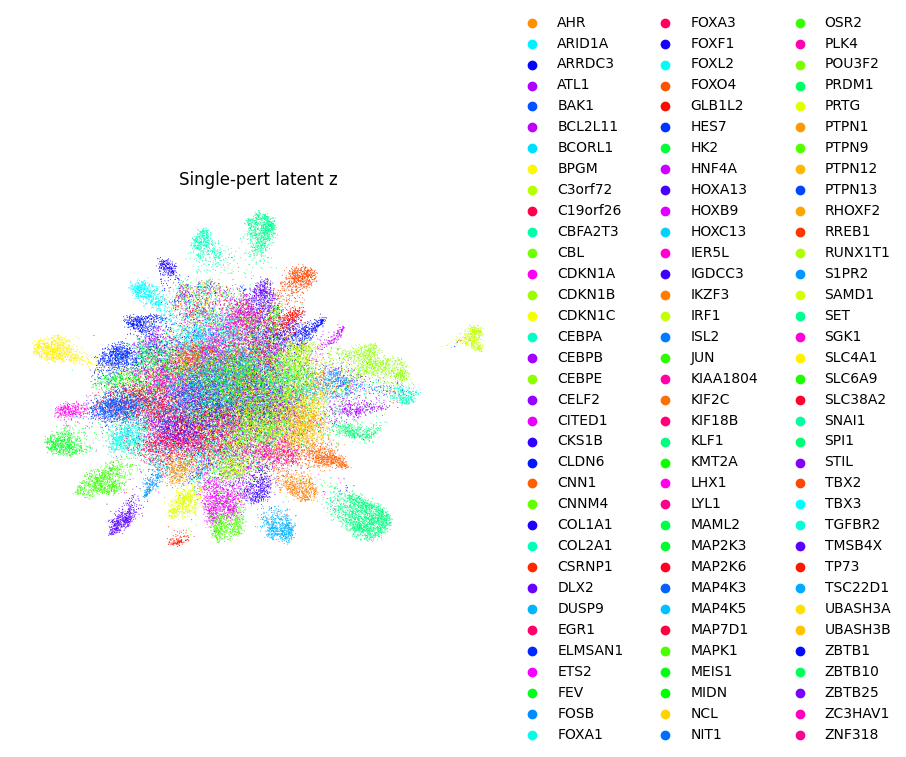

In [ ]:
import random

single_mask = (
    (data.obs[p_key] != NTC) &
    (~data.obs['perturbation_name'].astype(str).str.contains(r'\+', regex=True))
)
sub = data[single_mask].copy()

sc.pp.neighbors(sub, n_neighbors=15, use_rep='z')
sc.tl.umap(sub)

n_cats  = sub.obs[p_key].nunique()
palette = sns.color_palette('hsv', n_colors=n_cats)
random.shuffle(palette)
sc.pl.umap(sub, color=p_key, palette=palette, frameon=False, title='Single-pert latent z')

## Perturbation embedding correlation (rho_corr)

/opt/conda/envs/perturb/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/opt/conda/envs/perturb/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


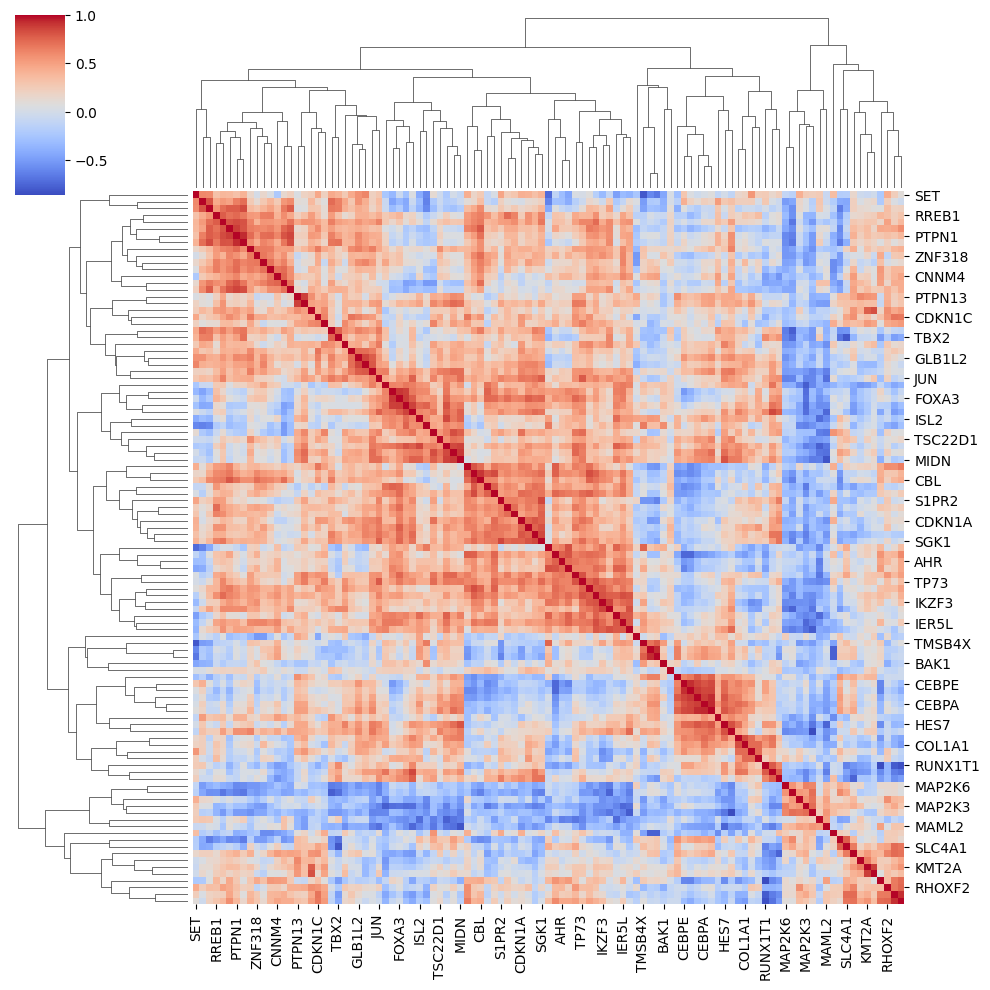

In [27]:
slk.pl.plot_corr(data)

## ATE — counterfactual effect prediction

**Protocol**
1. Encode NTC cells → background `z0_i`
2. K-means centroids `c_k` in background space (K=25)
3. For each perturbation `p`:  
   — single: `z_cf = c_k * (1 − W[p]) + A[p]*W[p]`  
   — combo `A+B`: `z_cf = c_k * (1 − max(W_A, W_B)) + A_A*W_A + A_B*W_B`
4. Decode → expected counts, log2-CPM normalise, subtract NTC baseline
5. Pearson r vs observed `treat_effect`

In [13]:
ate = model.predict_counterfactual_effects(
    data,
    n_centroids=25,
    observed_effect=data.uns['treat_effect'],
    approximate=False
)
print(f"Pearson r (predicted vs observed ATE, all perts): {ate['corr']:.4f}")

Pearson r (predicted vs observed ATE, all perts): 0.8678


In [28]:
# Break down by single vs combo perturbations
from scipy.stats import pearsonr

pred_df = ate['predicted_df']
obs_df  = ate['observed_df']

single_idx = [p for p in pred_df.index if '+' not in str(p)]
combo_idx  = [p for p in pred_df.index if '+' in str(p)]

def _r(idx):
    if not idx:
        return float('nan')
    x = pred_df.loc[idx].values.ravel()
    y = obs_df.loc[idx].values.ravel()
    v = np.isfinite(x) & np.isfinite(y)
    return pearsonr(x[v], y[v])[0] if v.sum() > 2 else float('nan')

print(f"  Single perts ({len(single_idx):3d}): Pearson r = {_r(single_idx):.4f}")
print(f"  Combo  perts ({len(combo_idx):3d}): Pearson r = {_r(combo_idx):.4f}")

  Single perts (105): Pearson r = 0.8017
  Combo  perts (131): Pearson r = 0.8575


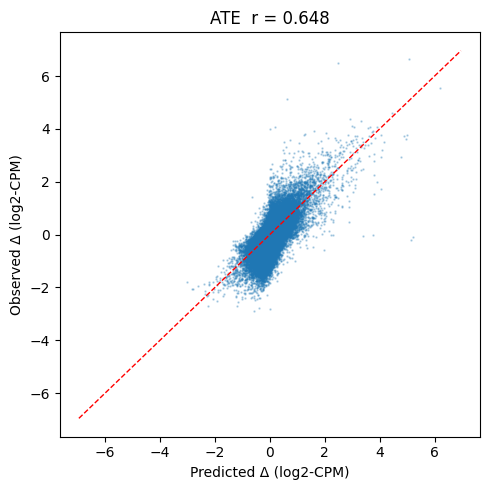

In [ ]:
# Scatter: predicted vs observed ATE (all perts, flattened over genes)
x_flat = pred_df.values.ravel()
y_flat = obs_df.values.ravel()
valid  = np.isfinite(x_flat) & np.isfinite(y_flat)

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(x_flat[valid], y_flat[valid], s=0.5, alpha=0.3, rasterized=True)
lim = max(abs(x_flat[valid]).max(), abs(y_flat[valid]).max()) * 1.05
ax.plot([-lim, lim], [-lim, lim], 'r--', lw=1)
ax.set_xlabel('Predicted Δ (log2-CPM)')
ax.set_ylabel('Observed Δ (log2-CPM)')
ax.set_title(f'ATE  r = {ate["corr"]:.3f}')
plt.tight_layout()
plt.show()

## z_corr vs rho_corr consistency

In [29]:
from scipy.stats import pearsonr, spearmanr

z_corr   = data.uns['results']['z_corr']
rho_corr = data.uns['results']['rho_corr']

pearson  = pearsonr(z_corr.flatten(),  rho_corr.flatten())
spearman = spearmanr(z_corr.flatten(), rho_corr.flatten())
print(f"Spearman ρ = {spearman.statistic:.3f}  (p = {spearman.pvalue:.1e})")
print(f" Pearson  r = {pearson.statistic:.3f}  (p = {pearson.pvalue:.1e})")

Spearman ρ = 0.769  (p = 0.0e+00)
 Pearson  r = 0.788  (p = 0.0e+00)


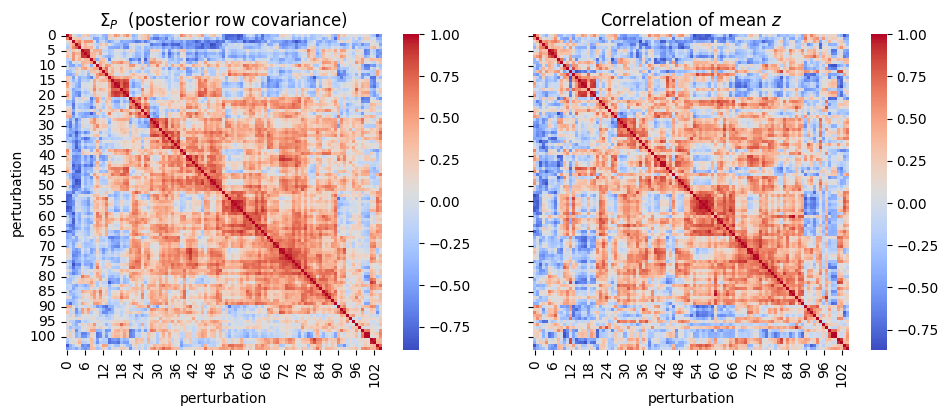

In [16]:
slk.pl.plot_zcorr(data)

## Gate W analysis

`W[p]` is a HardConcrete gate of shape `(P, d)`. Near-binary values indicate the model has learned sparse, perturbation-specific latent dimensions.

W shape: (105, 16)


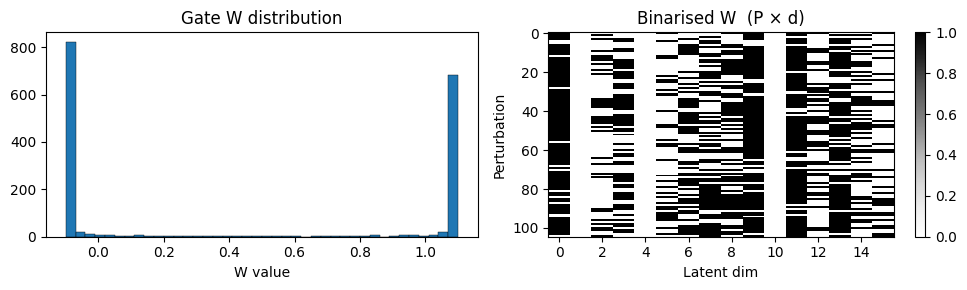

Avg active dims per pert: 7.3 / 16


In [30]:
W = data.uns['results']['W']   # (P, latent_dim)
print(f"W shape: {W.shape}")

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].hist(W.flatten(), bins=40, edgecolor='k', linewidth=0.3)
axes[0].set_title('Gate W distribution')
axes[0].set_xlabel('W value')

W_bin = (W > 0.5).astype(float)
im = axes[1].imshow(W_bin, aspect='auto', cmap='Greys', interpolation='nearest')
axes[1].set_title('Binarised W  (P × d)')
axes[1].set_xlabel('Latent dim')
axes[1].set_ylabel('Perturbation')
plt.colorbar(im, ax=axes[1])
plt.tight_layout()
plt.show()

print(f"Avg active dims per pert: {W_bin.sum(1).mean():.1f} / {W.shape[1]}")

## Perturbation clustering

Cluster `rho_corr` (correlation of learned `A[p]` vectors) and visualise groups on the single-pert UMAP.

In [ ]:
rho_perts = data.uns['results']['rho_perts']
C = rho_corr
print(f"rho_corr: {C.shape}  |  perts: {len(rho_perts)}")

rho_corr: (105, 105)  |  perts: 105


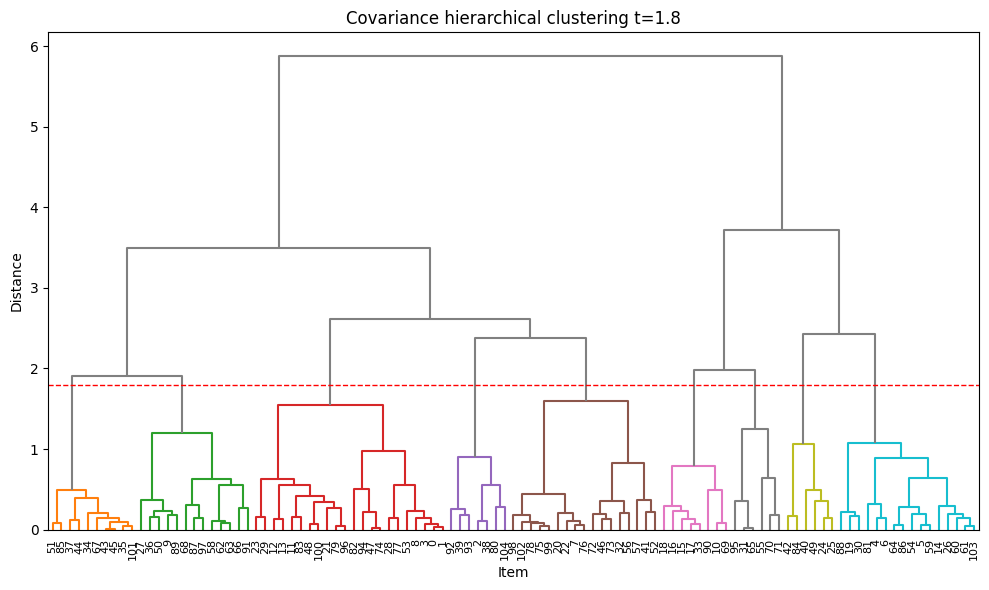

,group
AHR,3
ARID1A,3
ARRDC3,4
ATL1,3
BAK1,9
...,...
ZBTB1,3
ZBTB10,1
ZBTB25,5
ZC3HAV1,9


In [ ]:
groups       = slk.tl.cluster_rho(data, t=1.8, rho_corr=C, show=True)
named_groups = slk.tl.group2name(groups, list(rho_perts))
named_groups

pert_group
1     4557
2     6828
3    11248
4     3530
5     8490
6     4741
7     5575
8     2698
9    10068
Name: count, dtype: int64


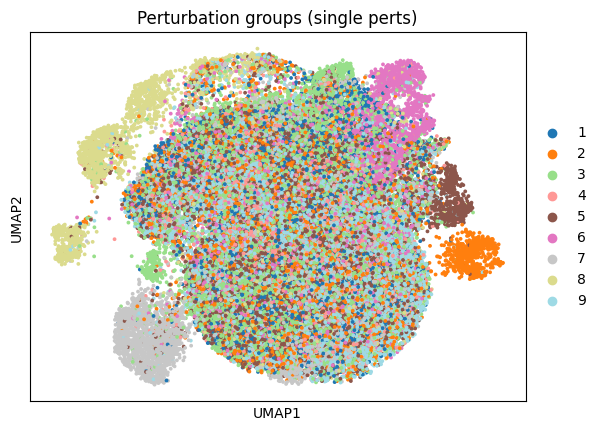

In [ ]:
# Colour single-pert UMAP by learned perturbation group
gene_to_group = named_groups['group'].to_dict()
sub.obs['pert_group'] = sub.obs[p_key].map(gene_to_group).fillna(-1).astype('category')

print(sub.obs['pert_group'].value_counts().sort_index())
sc.pl.umap(sub, color=['pert_group'], title='Perturbation groups (single perts)', palette='tab20', size=30)

## Synergy scoring

In [ ]:
erythroid = [
    # Globins
    "HBA1", "HBA2", "HBB", "HBG1", "HBG2", "HBE1", "HBZ", "HBD",
    # Membrane/structural
    "GYPA", "GYPB", "GYPC", "SLC4A1", "EPB42", "EPB41",
    "ANK1", "SPTA1", "SPTB", "RHAG",
    # Heme synthesis
    "ALAS2", "ALAD", "HMBS", "UROS", "UROD", "CPOX", "PPOX", "FECH", "TMEM14C",
    # Iron/chaperone
    "AHSP", "TFRC", "SLC25A37", "STEAP3", "FTH1", "FTL",
    # Transcription factors
    "KLF1", "GATA1", "TAL1", "ZFPM1", "NFE2", "LMO2", "MYB",
    # Signaling
    "EPOR", "STAT5A",
    # Metabolism
    "CA1", "CA2", "PKLR", "BPGM", "KCNN4",
    # Maturation
    "BNIP3L",
]

myeloid = [
    "SPI1", "CEBPA", "CEBPB", "CEBPE",
    "MPO", "ELANE", "LYZ", "S100A8", "S100A9", "CSF3R"
]

ifn_stress = [
    "IRF1", "STAT1", "ISG15", "IFIT1", "IFIT2", "IFIT3",
    "MX1", "OAS1", "DDIT3", "HSPA1A"
]

proliferation = [
    "MKI67", "TOP2A", "PCNA", "MCM2", "MCM3", "MCM4",
    "MCM5", "MCM6", "MCM7"
]

gene_sets = {
    "erythroid": erythroid,
    "myeloid": myeloid,
    "ifn_stress": ifn_stress,
    "proliferation": proliferation,
}

for name, genes in gene_sets.items():
    genes = [g for g in genes if g in data.var_names]
    sc.tl.score_genes(data, genes, score_name=f"{name}_score")

In [ ]:
import pandas as pd
import numpy as np

p_key = slk.configs.get_config('pert_key')
NTC   = slk.configs.get_config('ntc_label')

SYN_COLOR = '#2166ac'
EPI_COLOR = '#d73027'

# ── Synergy DataFrame — z-score residuals separately ──────────────────
syn = pd.DataFrame(data.uns['results']['synergy'])
pr  = syn['proj_residual'].values.astype(float)
dr  = syn['dom_residual'].values.astype(float)
ist = syn['interaction_score'].values.astype(float)
syn['proj_residual_z']    = (pr  - np.nanmean(pr))  / (np.nanstd(pr)  + 1e-10)
syn['dom_residual_z']     = (dr  - np.nanmean(dr))  / (np.nanstd(dr)  + 1e-10)
syn['interaction_score_z'] = (ist - np.nanmean(ist)) / (np.nanstd(ist) + 1e-10)

def _find_pair(df, a, b):
    for k in [f"{a}+{b}", f"{b}+{a}"]:
        if k in df.index:
            return k
    return None

required_syn_key = _find_pair(syn, 'CBL', 'CNN1')
required_epi_key = (_find_pair(syn, 'DUSP9', 'ETS1') or _find_pair(syn, 'DUSP9', 'ETS2'))

# Synergy: top proj_residual; Epistasis: top dom_residual
syn_cands = syn[syn['classification'] == 'latent synergy candidate']\
    .sort_values('proj_residual', ascending=False)
epi_cands = syn[syn['classification'] == 'dominance epistasis']\
    .sort_values('dom_residual', ascending=False)

def _build_list(required, pool, n=5):
    out = [required] if required and required in syn.index else []
    for idx in pool.index:
        if idx not in out and len(out) < n:
            out.append(idx)
    return out

syn_pairs    = _build_list(required_syn_key, syn_cands)
epi_pairs    = _build_list(required_epi_key, epi_cands)
selected     = syn_pairs + epi_pairs
selected_syn = set(syn_pairs)
selected_epi = set(epi_pairs)

print("Synergy pairs:  ", syn_pairs)
print("Epistatic pairs:", epi_pairs)

# ── NTC-centred deltas ─────────────────────────────────────────────────
z          = data.obsm['z']
pert_obs   = data.obs[p_key].astype(str).values
mean_z_ntc = z[pert_obs == NTC].mean(0)

def _delta(p):
    return z[pert_obs == p].mean(0) - mean_z_ntc


Synergy pairs:   ['CBL+CNN1', 'DLX2+ZBTB10', 'CNN1+UBASH3B', 'S1PR2+SGK1', 'CEBPE+SPI1']
Epistatic pairs: ['DUSP9+ETS2', 'ELMSAN1+LHX1', 'IKZF3+MAP2K6', 'ELMSAN1+ZBTB10', 'CEBPA+KLF1']


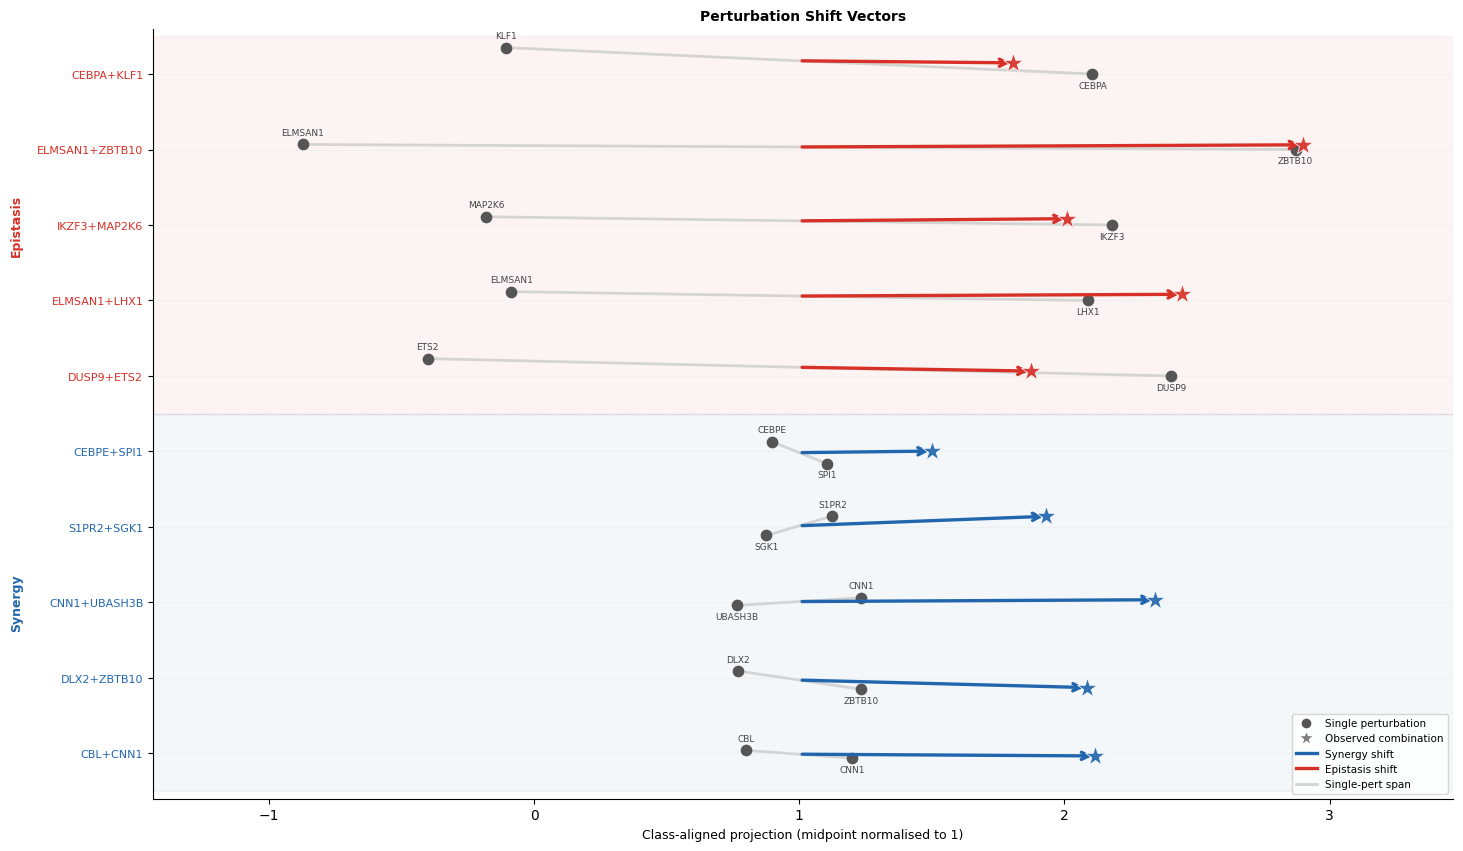

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

_eps = 1e-8

def _unit(x, eps=1e-8):
    x = np.asarray(x, dtype=float)
    n = np.linalg.norm(x)
    return x / n if n > eps else None


def _decompose_full(da, db, dab, mode="shared", dominant_pert=None, pert_a=None, pert_b=None, eps=1e-8):
    ua = _unit(da, eps)
    ub = _unit(db, eps)
    if ua is None or ub is None:
        return None

    if mode == "dominant":
        if dominant_pert == pert_a:
            e1, other = ua, ub
        elif dominant_pert == pert_b:
            e1, other = ub, ua
        else:
            e1, other = _unit(ua + ub, eps), ua - ub
    else:
        e1, other = _unit(ua + ub, eps), ua - ub

    if e1 is None:
        return None

    e2_raw = other - np.dot(other, e1) * e1
    e2 = _unit(e2_raw, eps)
    if e2 is None:
        tmp = np.zeros_like(e1)
        tmp[np.argmin(np.abs(e1))] = 1.0
        e2 = _unit(tmp - np.dot(tmp, e1) * e1, eps)

    def _p(v):
        return float(np.dot(v, e1)), (float(np.dot(v, e2)) if e2 is not None else 0.0)

    de = 0.5 * (da + db)
    return dict(A=_p(da), B=_p(db), E=_p(de), AB=_p(dab),
                interaction_norm=float(np.linalg.norm(dab - de)))


pairs_ordered = syn_pairs + epi_pairs
n_syn   = len(syn_pairs)
n_pairs = len(pairs_ordered)

# Compute decompositions
row_data = []
for pair_key in pairs_ordered:
    row = syn.loc[pair_key]
    na, nb = row['pert_a'], row['pert_b']
    has_data = (pert_obs == na).any() and (pert_obs == nb).any() and (pert_obs == pair_key).any()
    if not has_data:
        row_data.append(None)
        continue
    mode = "dominant" if row['classification'] == "dominance epistasis" else "shared"
    row_data.append(_decompose_full(
        _delta(na), _delta(nb), _delta(pair_key),
        mode=mode, dominant_pert=row.get('dominant_pert'),
        pert_a=na, pert_b=nb, eps=_eps,
    ))

all_y_raw = [r[k][1] for r in row_data if r for k in ('A', 'B', 'E', 'AB')]
y_scale = 0.35 / (max((abs(v) for v in all_y_raw), default=1.0) + _eps)

fig, ax = plt.subplots(figsize=(20, max(6, n_pairs * 0.8 + 2)))

ax.axhspan(-0.5,        n_syn - 0.5,   alpha=0.05, color=SYN_COLOR, zorder=0)
ax.axhspan(n_syn - 0.5, n_pairs - 0.5, alpha=0.05, color=EPI_COLOR, zorder=0)
ax.axhline(n_syn - 0.5, color='#ccc', lw=0.8, linestyle=':', zorder=0)

x_all = []
for row_i, (pair_key, result) in enumerate(zip(pairs_ordered, row_data)):
    color = SYN_COLOR if pair_key in selected_syn else EPI_COLOR
    row   = syn.loc[pair_key]
    na, nb = row['pert_a'], row['pert_b']

    ax.axhline(row_i, color='#eee', lw=0.5, zorder=0)

    if result is None:
        ax.text(1.0, row_i, '(no data)', fontsize=7, ha='center', va='center', color='#aaa')
        continue

    e_x = result['E'][0]
    norm = abs(e_x) + _eps

    A_xn  = result['A'][0]  / norm
    B_xn  = result['B'][0]  / norm
    E_xn  = 1.0
    AB_xn = result['AB'][0] / norm

    A_yp  = row_i + result['A'][1]  * y_scale
    B_yp  = row_i + result['B'][1]  * y_scale
    E_yp  = row_i + result['E'][1]  * y_scale
    AB_yp = row_i + result['AB'][1] * y_scale

    x_all.extend([A_xn, B_xn, AB_xn])

    ax.plot([A_xn, B_xn], [A_yp, B_yp], '-', color='#d4d4d4', lw=2.0, zorder=1, solid_capstyle='round')
    ax.annotate('', xy=(AB_xn, AB_yp), xytext=(E_xn, E_yp),
                arrowprops=dict(arrowstyle='->', color=color, lw=2.4, mutation_scale=13), zorder=4)
    ax.scatter(A_xn,  A_yp,  s=55,  c='#555', marker='o', zorder=3)
    ax.scatter(B_xn,  B_yp,  s=55,  c='#555', marker='o', zorder=3)
    ax.scatter(AB_xn, AB_yp, s=220, c=color,  marker='*', zorder=5,
               edgecolors='white', linewidths=0.6, alpha=0.92)

    va_a = 'bottom' if A_yp >= B_yp else 'top'
    va_b = 'top'    if A_yp >= B_yp else 'bottom'
    ax.annotate(na, (A_xn, A_yp), fontsize=6.5, ha='center', va=va_a,
                xytext=(0, 5 if va_a == 'bottom' else -5), textcoords='offset points', color='#444')
    ax.annotate(nb, (B_xn, B_yp), fontsize=6.5, ha='center', va=va_b,
                xytext=(0, -5 if va_b == 'top' else 5), textcoords='offset points', color='#444')

# Y-axis: just pair names
ax.set_yticks(range(n_pairs))
ax.set_yticklabels(pairs_ordered, fontsize=8)
for tick, pair_key in zip(ax.get_yticklabels(), pairs_ordered):
    tick.set_color(SYN_COLOR if pair_key in selected_syn else EPI_COLOR)

if x_all:
    lo, hi = min(x_all), max(x_all)
    pad = max((hi - lo) * 0.15, 0.3)
    ax.set_xlim(lo - pad, hi + pad)
ax.set_ylim(-0.6, n_pairs - 0.4)
ax.set_xlabel('Class-aligned projection (midpoint normalised to 1)', fontsize=9)
ax.set_title('Perturbation Shift Vectors', fontsize=10, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)

# Synergy / Epistasis labels — further left to clear y-tick labels
ax.text(-0.10, (n_syn - 1) / 2, 'Synergy',
        transform=ax.get_yaxis_transform(), fontsize=9, fontweight='bold',
        color=SYN_COLOR, ha='right', va='center', rotation=90)
ax.text(-0.10, n_syn + (n_pairs - n_syn - 1) / 2, 'Epistasis',
        transform=ax.get_yaxis_transform(), fontsize=9, fontweight='bold',
        color=EPI_COLOR, ha='right', va='center', rotation=90)

legend_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#555', markersize=8,
           label='Single perturbation'),
    Line2D([0], [0], marker='*', color='w', markerfacecolor='gray', markersize=12,
           label='Observed combination'),
    Line2D([0], [0], color=SYN_COLOR, lw=2.4, label='Synergy shift'),
    Line2D([0], [0], color=EPI_COLOR, lw=2.4, label='Epistasis shift'),
    Line2D([0], [0], color='#d4d4d4', lw=2.0, label='Single-pert span'),
]
ax.legend(handles=legend_handles, loc='lower right', fontsize=7.5, frameon=True)

fig.subplots_adjust(left=0.25)
plt.show()


In [ ]:
syn[syn.index.str.contains('OSR2')]

,pert_a,pert_b,dominant_pert,n_a,n_b,n_ab,cos_a_b,cos_ab_a,cos_ab_b,cos_ab_shared,proj_residual,classification,proj_residual_z
CEBPB+OSR2,CEBPB,OSR2,None,487,1002,211,0.518737,0.908942,0.811998,0.987437,1.474980,latent synergy candidate,0.084840
FOSB+OSR2,FOSB,OSR2,None,630,1002,382,0.435361,0.809426,0.876288,0.994920,2.068919,mixed / ambiguous,0.877802
OSR2+PTPN12,OSR2,PTPN12,OSR2,1002,445,338,-0.595607,0.837684,-0.138227,0.777757,0.096475,dominance epistasis,-1.755589
OSR2+UBASH3B,OSR2,UBASH3B,OSR2,1002,1201,795,-0.562060,0.968559,-0.508198,0.491900,-0.056332,dominance epistasis,-1.959601


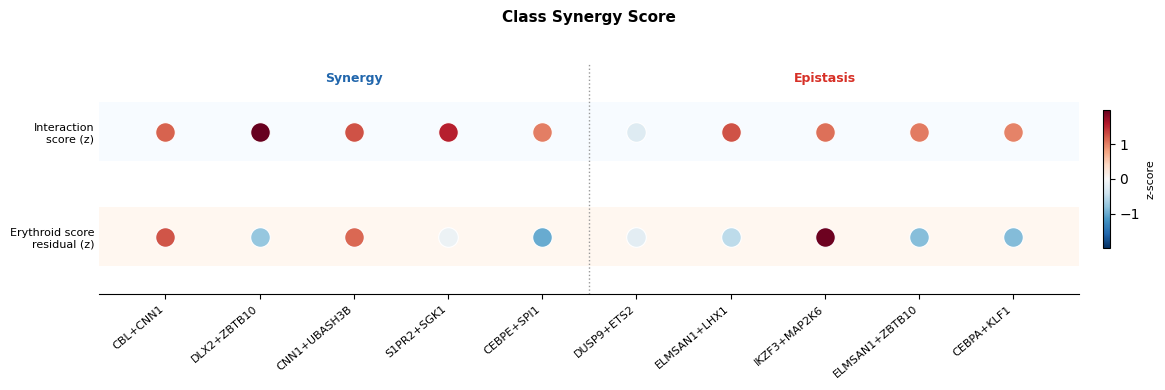

In [ ]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors

pairs       = [p for p in selected if p in syn.index]
n_pairs     = len(pairs)
n_syn_shown = sum(1 for p in pairs if p in selected_syn)

# ── Interaction score z-score (top row) ───────────────────────────────
interaction_z = np.array([float(syn.loc[p, 'interaction_score_z']) for p in pairs])

# ── Erythroid score residual (bottom row) ─────────────────────────────
ery_raw = np.full(n_pairs, np.nan)
for j, pair in enumerate(pairs):
    row = syn.loc[pair]
    na, nb = row['pert_a'], row['pert_b']
    mask_ab = data.obs[p_key] == pair
    mask_a  = data.obs[p_key] == na
    mask_b  = data.obs[p_key] == nb
    if mask_ab.any() and mask_a.any() and mask_b.any():
        ery_raw[j] = (
            data.obs.loc[mask_ab, 'erythroid_score'].mean()
            - 0.5 * (data.obs.loc[mask_a, 'erythroid_score'].mean()
                     + data.obs.loc[mask_b, 'erythroid_score'].mean())
        )

valid = np.isfinite(ery_raw)
if valid.sum() > 1:
    ery_z = (ery_raw - np.nanmean(ery_raw)) / (np.nanstd(ery_raw) + 1e-10)
else:
    ery_z = ery_raw.copy()

# ── Shared diverging colormap across both rows ─────────────────────────
all_z = np.concatenate([interaction_z[np.isfinite(interaction_z)], ery_z[np.isfinite(ery_z)]])
vabs  = float(np.abs(all_z).max()) if len(all_z) > 0 else 1.0
cmap  = plt.cm.RdBu_r
norm  = mcolors.Normalize(vmin=-vabs, vmax=vabs)

DOT_SIZE = 200
x_pos    = np.arange(n_pairs)

fig, ax = plt.subplots(figsize=(max(8, n_pairs * 1.1 + 2), 4))

# Row backgrounds
for y, c in [(1.0, '#f7fbff'), (0.0, '#fff7f0')]:
    ax.axhspan(y - 0.28, y + 0.28, color=c, zorder=0, lw=0)

# Synergy / epistasis divider
if 0 < n_syn_shown < n_pairs:
    ax.axvline(n_syn_shown - 0.5, color='#999', lw=1.0, linestyle=':', zorder=2)

# Top row: interaction score
for j, zv in enumerate(interaction_z):
    c = [cmap(norm(zv))] if np.isfinite(zv) else ['#ddd']
    ax.scatter(j, 1.0, s=DOT_SIZE, c=c, edgecolors='white', linewidths=0.8, zorder=3)

# Bottom row: erythroid score residual
for j, zv in enumerate(ery_z):
    c = [cmap(norm(zv))] if np.isfinite(zv) else ['#ddd']
    ax.scatter(j, 0.0, s=DOT_SIZE, c=c, edgecolors='white', linewidths=0.8, zorder=3)

# Section labels above top row
if n_syn_shown > 0:
    ax.text(n_syn_shown / 2 - 0.5, 1.45, 'Synergy',
            ha='center', va='bottom', fontsize=9, fontweight='bold', color=SYN_COLOR)
if n_syn_shown < n_pairs:
    ax.text(n_syn_shown + (n_pairs - n_syn_shown) / 2 - 0.5, 1.45, 'Epistasis',
            ha='center', va='bottom', fontsize=9, fontweight='bold', color=EPI_COLOR)

ax.set_yticks([0.0, 1.0])
ax.set_yticklabels(['Erythroid score\nresidual (z)', 'Interaction\nscore (z)'], fontsize=8)
ax.set_xticks(x_pos)
ax.set_xticklabels(pairs, rotation=40, ha='right', fontsize=8)
ax.set_xlim(-0.7, n_pairs - 0.3)
ax.set_ylim(-0.55, 1.65)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.tick_params(axis='y', length=0)

# Colorbar
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, shrink=0.6, pad=0.02)
cbar.set_label('z-score', fontsize=8)

ax.set_title('Class Synergy Score', fontsize=11, fontweight='bold', pad=30)
plt.tight_layout()
plt.show()


In [ ]:
syn[syn.index.str.contains('DUSP9')]

,pert_a,pert_b,dominant_pert,n_a,n_b,n_ab,cos_a_b,cos_ab_a,cos_ab_b,cos_ab_shared,proj_residual,dom_residual,interaction_score,classification,proj_residual_z,dom_residual_z,interaction_score_z
DUSP9+ETS2,DUSP9,ETS2,DUSP9,729,1201,786,-0.244707,0.961244,-0.011786,0.772508,0.440797,1.461021,1.647123,dominance epistasis,-1.295887,-0.061679,-0.258339
DUSP9+IGDCC3,DUSP9,IGDCC3,None,729,613,382,0.535926,0.903552,0.830651,0.989464,1.422022,1.300323,1.533467,latent synergy candidate,0.014136,-0.275245,-0.410851
DUSP9+KLF1,DUSP9,KLF1,None,729,1954,366,0.053323,0.653812,0.756149,0.971430,2.416852,2.024684,2.744447,mixed / ambiguous,1.342324,0.687427,1.214145
DUSP9+MAPK1,DUSP9,MAPK1,None,729,763,290,-0.264993,0.714772,0.413991,0.930983,-0.299227,0.078752,0.821201,mixed / ambiguous,-2.283887,-1.898709,-1.366632
DUSP9+PRTG,DUSP9,PRTG,None,729,684,297,0.518618,0.881748,0.854415,0.996211,1.605561,1.392356,1.654632,latent synergy candidate,0.259178,-0.152935,-0.248263
DUSP9+SNAI1,DUSP9,SNAI1,None,729,466,182,0.277514,0.733017,0.811169,0.966055,3.010686,2.961030,3.453320,mixed / ambiguous,2.135147,1.931828,2.165374


<Axes: xlabel='dom_residual', ylabel='Count'>

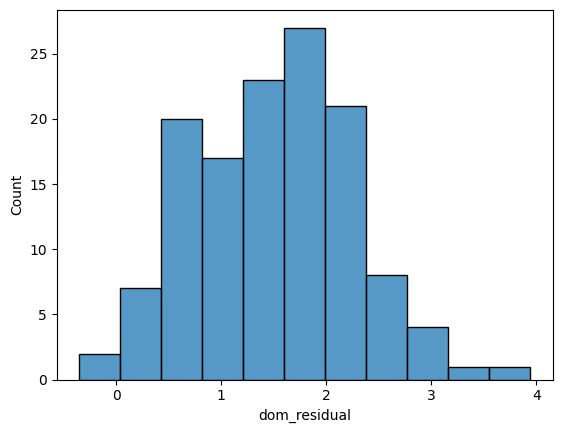

In [ ]:
sns.histplot(syn['dom_residual'])